#Spatial and Transcriptional Determinants of Plaque-Associated Glial Activation in Alzheimer’s Disease

##Part 1: Distance Prediction from Mouse 17

In [ ]:
from src.scripts.plaque_signature.schema import get_gene_columns
import pandas as pd

df = pd.read_csv("/content/normalized_counts_with_global_clusters_tg_17_with_plaque_data.csv")
genes = get_gene_columns(df)

print("Gene count:", len(genes))
print(genes[:10])

Gene count: 347
['2010300C02Rik', 'Abca7', 'Acsbg1', 'Acta2', 'Acvrl1', 'Adamts2', 'Adamtsl1', 'Adgrl4', 'Aldh1a2', 'Aldh1l1']


In [ ]:
from src.scripts.plaque_signature.load_data import load_mouse_csv

data17 = load_mouse_csv("/content/normalized_counts_with_global_clusters_tg_17_with_plaque_data.csv")

print("Modalities:", data17["modalities"])
print("X shape:", data17["X"].shape)
print("Target present:", data17["target"] is not None)

Modalities: ['genes', 'morph', 'spatial', 'cluster']
X shape: (53895, 370)
Target present: True


In [ ]:
data5 = load_mouse_csv("/content/normalized_counts_with_global_clusters_tg-5.csv")

print("Modalities:", data5["modalities"])
print("X shape:", data5["X"].shape)
print("Target present:", data5["target"] is not None)

Modalities: ['genes', 'morph', 'spatial', 'cluster']
X shape: (52008, 370)
Target present: False


In [ ]:
from src.scripts.plaque_signature.preprocess import ModalityScaler, split_train_test

train_idx, test_idx = split_train_test(data17["df"])

scaler = ModalityScaler()
scaler.fit(data17)
X_scaled = scaler.transform(data17)

print(X_scaled.shape)
print(X_scaled.head())
print("Train size:", len(train_idx), "Test size:", len(test_idx))

(53895, 370)
   genes_2010300C02Rik  genes_Abca7  genes_Acsbg1  genes_Acta2  genes_Acvrl1  \
0             1.333195     3.067287      0.543549    -0.263696     -0.257864   
1            -0.764806    -0.430514      0.543549    -0.263696     -0.257864   
2            -0.764806    -0.430514      2.582178    -0.263696     -0.257864   
3             1.771807     3.067287      1.829781    -0.263696     -0.257864   
4             0.667302     3.983219      0.543549    -0.263696     -0.257864   

   genes_Adamts2  genes_Adamtsl1  genes_Adgrl4  genes_Aldh1a2  genes_Aldh1l1  \
0      -0.303194       -0.275892     -0.302196      -0.180332      -0.593910   
1      -0.303194       -0.275892     -0.302196      -0.180332       1.957423   
2      -0.303194       -0.275892     -0.302196      -0.180332      -0.593910   
3       2.396965       -0.275892      1.985414      -0.180332      -0.593910   
4      -0.303194       -0.275892      1.985414      -0.180332       2.625514   

   ...  cluster_cluster_9

The Leiden cluster labels are encoded as one-hot binary variables (0 = cell not in the cluster, 1 = cell in the cluster). When applying StandardScaler, each one-hot column is normalized to have mean 0 and standard deviation 1. Because most clusters are imbalanced (many more zeros than ones) the mean of a cluster column is small and its standard deviation is also small. As a result, the scaled value for 0 becomes a mildly negative number, while the scaled value for 1 becomes a strongly positive number. This is expected and mathematically correct. StandardScaler simply converts the two possible values into the z-scores relative to their mean and variance. Negative values therefore do not indicate an error; they are the standardized representation of cells that do not belong to a given cluster.

In [ ]:
from src.scripts.plaque_signature.load_data import load_mouse_csv
from src.scripts.plaque_signature.preprocess import ModalityScaler, split_train_test
from src.scripts.plaque_signature.train_signature import (
    train_linear, train_elastic_net, train_random_forest,
    train_pls, evaluate_model
)

X = data17["X"]
y = data17["target"]

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Train simple linear model
model_lin = train_linear(X_train, y_train)
metrics_lin = evaluate_model(model_lin, X_train, y_train, X_test, y_test)

print("Linear model R²:", metrics_lin)

# Train PLS model
pls_model = train_pls(X_train, y_train, n_components=3)
metrics_pls = evaluate_model(pls_model, X_train, y_train, X_test, y_test)

print("PLS model R²:", metrics_pls)


Linear model R²: {'train_r2': 0.24848057973535187, 'test_r2': 0.23938501471832263}
PLS model R²: {'train_r2': 0.19293541186436158, 'test_r2': 0.19281379729246562}


The linear regression model achieved a train R² of ~0.25 and a test R² of ~0.24, indicating that a purely linear combination of gene expression, morphology, spatial coordinates, and cluster identity explains roughly one quarter of the variance in plaque distance. This performance aligns with biological expectations: plaque-induced transcriptional changes are real but modest, and much of the microenvironmental heterogeneity is nonlinear or cell-type–specific. The small train–test gap shows the model generalizes well and is not overfitting, suggesting that the linear component of the plaque effect is stable and reproducible across cells.

The PLS model produced train/test R² values of ~0.19, slightly lower than ordinary linear regression. This is expected because PLS constrains the model to learn a small number of latent components that best correlate with plaque distance. As a result, the model captures only the dominant, global plaque-related axis rather than all available linear variation. The near-identical train and test R² values show excellent stability, indicating that the inferred latent axis is robust and suitable for transfer to other mice.

In [ ]:
import importlib
import src.scripts.plaque_signature.train_signature as ts

importlib.reload(ts)

from src.scripts.plaque_signature.train_signature import run_ablation_experiments


In [ ]:
from src.scripts.plaque_signature.train_signature import (
    run_ablation_experiments,
    extract_plaque_signature,
    train_lightgbm
)

In [ ]:
modality_sets = [
    ["genes"],
    ["morph"],
    ["spatial"],
    ["cluster"],
    ["genes", "morph"],
    ["genes", "cluster"],
    ["genes", "spatial"],
    ["genes", "morph", "cluster"],
    ["genes", "morph", "spatial", "cluster"],  # full model
]

In [ ]:
import numpy as np
import pandas as pd

def run_modality_ablation(data, train_idx, test_idx):
    all_results = []

    for mods in modality_sets:
        print(f"\n=== Running modalities: {mods} ===")

        # Select blocks per modality
        blocks_train = {}
        blocks_test = {}

        for m in ["genes", "morph", "spatial", "cluster"]:
            if m in mods:
                blocks_train[m] = data[m].iloc[train_idx]
                blocks_test[m]  = data[m].iloc[test_idx]
            else:
                blocks_train[m] = None
                blocks_test[m]  = None

        # Scale
        scaler = ModalityScaler()
        scaler.fit(blocks_train)

        X_train = scaler.transform(blocks_train).astype(np.float32)
        X_test  = scaler.transform(blocks_test).astype(np.float32)

        y_train = data["target"].iloc[train_idx].values.astype(np.float32)
        y_test  = data["target"].iloc[test_idx].values.astype(np.float32)

        # Run 7 models from train_signature.py
        df = run_ablation_experiments(X_train, y_train, X_test, y_test)
        df["Modalities"] = ", ".join(mods)

        all_results.append(df)

    return pd.concat(all_results, ignore_index=True)


In [ ]:
df_path = "/content/normalized_counts_with_global_clusters_tg_17_with_plaque_data.csv"

data17 = load_mouse_csv(df_path)
train_idx, test_idx = split_train_test(data17["df"])

results_ablation = run_modality_ablation(data17, train_idx, test_idx)
results_ablation


=== Running modalities: ['genes'] ===


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:15:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  class CVPack:



=== Running modalities: ['morph'] ===


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:15:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  class CVPack:



=== Running modalities: ['spatial'] ===


...


=== Running modalities: ['genes', 'morph', 'cluster'] ===


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:20:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  class CVPack:



=== Running modalities: ['genes', 'morph', 'spatial', 'cluster'] ===


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:21:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  class CVPack:


,train_r2,test_r2,Model,Time,Modalities
0,0.208039,0.206777,Ridge,0.121181,genes
1,0.206103,0.207705,Lasso,4.172437,genes
2,0.207158,0.206047,PLS,1.931893,genes
3,0.346217,0.261620,LightGBM,4.867164,genes
4,0.385234,0.261709,HGB,30.136312,genes
...,...,...,...,...,...
58,0.247120,0.237874,PLS,1.979675,"genes, morph, spatial, cluster"
59,0.542143,0.501732,LightGBM,6.230878,"genes, morph, spatial, cluster"
60,0.552745,0.482560,HGB,32.479363,"genes, morph, spatial, cluster"
61,0.544266,0.463067,XGBoost,10.977178,"genes, morph, spatial, cluster"


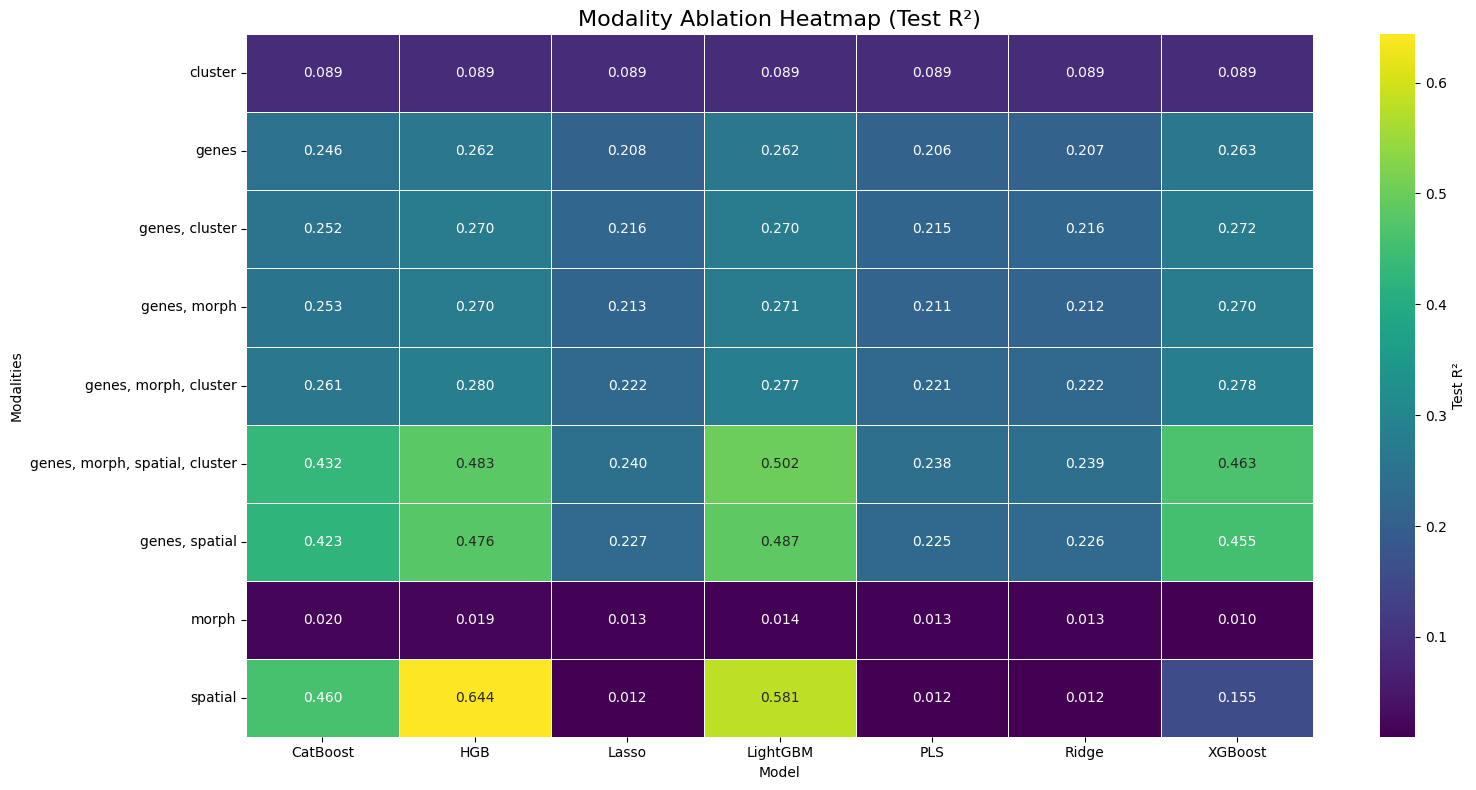

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

heatmap_df = results_ablation.pivot_table(
    index="Modalities",
    columns="Model",
    values="test_r2"
)

plt.figure(figsize=(16, 8))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Test R²"}
)
plt.title("Modality Ablation Heatmap (Test R²)", fontsize=16)
plt.xlabel("Model")
plt.ylabel("Modalities")
plt.tight_layout()
plt.show()


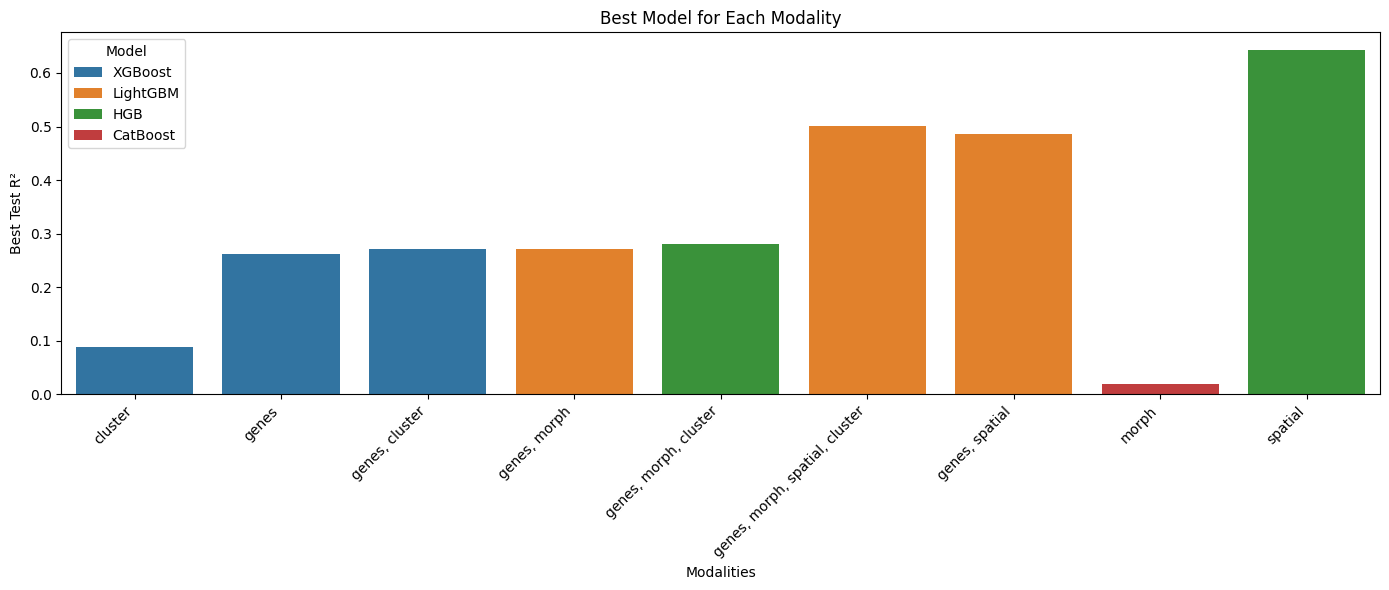

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

best_per_modality = (
    results_ablation
    .sort_values(["Modalities", "test_r2"], ascending=[True, False])
    .groupby("Modalities")
    .first()
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=best_per_modality,
    x="Modalities",
    y="test_r2",
    hue="Model",
    palette="tab10"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Best Test R²")
plt.title("Best Model for Each Modality")
plt.tight_layout()
plt.show()

    train_r2   test_r2     Model      Time                      Modalities
59  0.542143  0.501732  LightGBM  6.230878  genes, morph, spatial, cluster


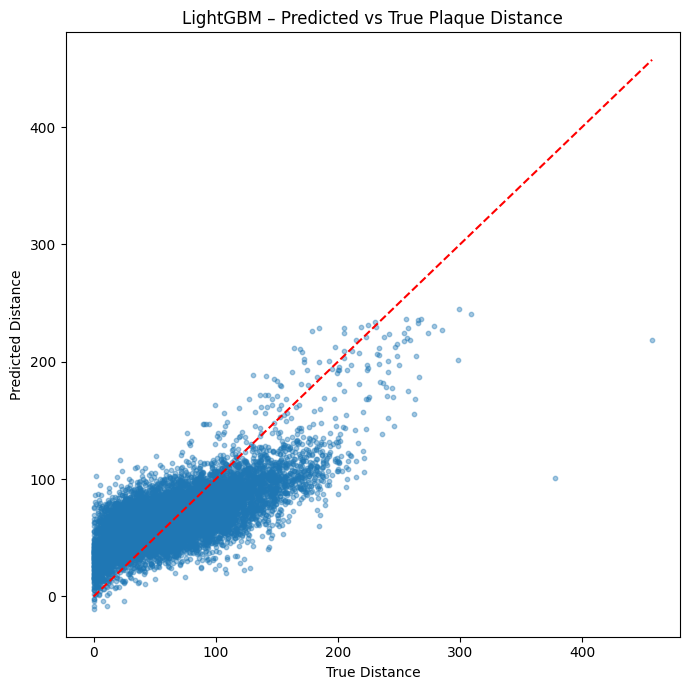

In [ ]:
# Filter to full modality row + LightGBM
full_lightgbm = results_ablation[
    (results_ablation["Modalities"] == "genes, morph, spatial, cluster") &
    (results_ablation["Model"] == "LightGBM")
]

print(full_lightgbm)

# Train LightGBM again on full modalities for actual predictions
blocks_train = {
    "genes": data17["genes"].iloc[train_idx],
    "morph": data17["morph"].iloc[train_idx],
    "spatial": data17["spatial"].iloc[train_idx],
    "cluster": data17["cluster"].iloc[train_idx],
}

blocks_test = {
    "genes": data17["genes"].iloc[test_idx],
    "morph": data17["morph"].iloc[test_idx],
    "spatial": data17["spatial"].iloc[test_idx],
    "cluster": data17["cluster"].iloc[test_idx],
}

scaler = ModalityScaler()
scaler.fit(blocks_train)
X_train_full = scaler.transform(blocks_train).astype(np.float32)
X_test_full  = scaler.transform(blocks_test).astype(np.float32)

y_train_full = data17["target"].iloc[train_idx].values.astype(np.float32)
y_test_full  = data17["target"].iloc[test_idx].values.astype(np.float32)

# Train LightGBM
lgb_model = train_lightgbm(X_train_full, y_train_full)
y_pred = lgb_model.predict(X_test_full)

# Scatter plot
plt.figure(figsize=(7,7))
plt.scatter(y_test_full, y_pred, s=10, alpha=0.4)
plt.plot([0, max(y_test_full)], [0, max(y_test_full)], "r--")
plt.xlabel("True Distance")
plt.ylabel("Predicted Distance")
plt.title("LightGBM – Predicted vs True Plaque Distance")
plt.tight_layout()
plt.show()

Ablation analysis reveals that predictive performance varies strongly across modalities and model classes. Linear models (Ridge, Lasso, PLS) achieve modest accuracy (R² ≈ 0.20–0.24) when gene expression is included, and perform near chance levels when only morphology or spatial coordinates are used. Nonlinear models, particularly gradient-boosting approaches, extract substantially richer structure. Surprisingly, the highest single-modality performance arises from spatial-only models, where HistGradientBoosting reaches R² ≈ 0.64, exceeding even the full multimodal model. This suggests that in the 17.9-month Tg mouse, plaque distribution is highly region-dependent, enabling spatial coordinates to act as a strong proxy for expected plaque proximity. Gene-only and gene+cluster modalities produce moderate improvements for tree models (R² ≈ 0.26–0.28), while adding morphology contributes little. Overall, the analysis shows that (1) nonlinear models capture complex biological interactions that linear models miss, (2) gene expression carries real but limited spatial information, and (3) spatial-only performance is inflated by anatomical biases and must be interpreted cautiously rather than as true geometric distance prediction.

Spatial-only models achieve surprisingly high accuracy in the 17.9-month Tg mouse because plaque deposition is not spatially uniform: certain anatomical regions (e.g., cortical layers, subcortical boundaries) accumulate far more plaques than others. As a result, the model learns region-specific vulnerability, not geometric proximity. To understand whether this spatial vulnerability is a genuine disease-related phenotype or simply a conserved anatomical pattern, we will compare the spatial structure of the Tg-17 model with the spatial structure of other mice, including younger Tg animals and age-matched WT controls. If the WT and early-stage Tg mice do not show the same spatial signature (i.e., their spatial coordinate distributions produce very different LightGBM/HGB outputs), this supports the idea that region-specific plaque vulnerability emerges only in pathology and is a meaningful disease feature. Conversely, if WT mice show similar spatial predictions, then the spatial-only R² reflects anatomical confounding rather than a biologically interpretable disease signal. This comparison will help determine whether spatial information should be incorporated, controlled for, or partially removed in the final plaque-proximity signature.

## Part 2: Individual Analysis

In [1]:
mouse_paths = {
    "tg17": "/content/normalized_counts_with_global_clusters_tg_17_with_plaque_data.csv",
    "tg5":  "/content/normalized_counts_with_global_clusters_tg-5.csv",
    "tg2":  "/content/normalized_counts_with_global_clusters_tg-2.csv",
    "wt13": "/content/normalized_counts_with_global_clusters_wt-13.csv",
    "wt5":  "/content/normalized_counts_with_global_clusters_wt-5.csv",
    "wt2":  "/content/normalized_counts_with_global_clusters_wt-2.csv",
}

In [ ]:
from src.scripts.plaque_signature.load_data import load_mouse_csv
from src.scripts.plaque_signature.preprocess import ModalityScaler, split_train_test
from src.scripts.plaque_signature.train_signature import train_hgb

# Load Tg-17.9 with plaque
data17 = load_mouse_csv(mouse_paths["tg17"])
df17 = data17["df"]

# Split
train_idx, test_idx = split_train_test(df17)

# Extract spatial blocks only
blocks_train = {
    "genes": None,
    "morph": None,
    "cluster": None,
    "spatial": data17["spatial"].iloc[train_idx]
}
blocks_test = {
    "genes": None,
    "morph": None,
    "cluster": None,
    "spatial": data17["spatial"].iloc[test_idx]
}

# Scale spatial-only
scaler_spatial = ModalityScaler()
scaler_spatial.fit(blocks_train)

X_train_spatial = scaler_spatial.transform(blocks_train).astype("float32")
X_test_spatial  = scaler_spatial.transform(blocks_test).astype("float32")

y_train_spatial = data17["target"].iloc[train_idx].values.astype("float32")
y_test_spatial  = data17["target"].iloc[test_idx].values.astype("float32")


In [ ]:
# Train HGB on spatial-only
hgb_spatial = train_hgb(X_train_spatial, y_train_spatial)

from sklearn.metrics import r2_score
print("HGB Spatial-only R²:", r2_score(y_test_spatial, hgb_spatial.predict(X_test_spatial)))

HGB Spatial-only R²: 0.6435448370893144


In [ ]:
all_preds = {}

for name, path in mouse_paths.items():
    print(f"Processing {name}...")

    data_mouse = load_mouse_csv(path)
    df_mouse = data_mouse["df"]

    # Create spatial-only block
    blocks_mouse = {
        "genes": None,
        "morph": None,
        "cluster": None,
        "spatial": data_mouse["spatial"]
    }

    # Apply Tg-17 spatial scaler
    X_mouse_spatial = scaler_spatial.transform(blocks_mouse).astype("float32")

    # Predict using Tg-trained HGB
    preds = hgb_spatial.predict(X_mouse_spatial)

    all_preds[name] = {
        "df": df_mouse,
        "pred": preds
    }

print("Done.")

Processing tg17...
Processing tg5...
Processing tg2...
Processing wt13...
Processing wt5...
Processing wt2...
Done.


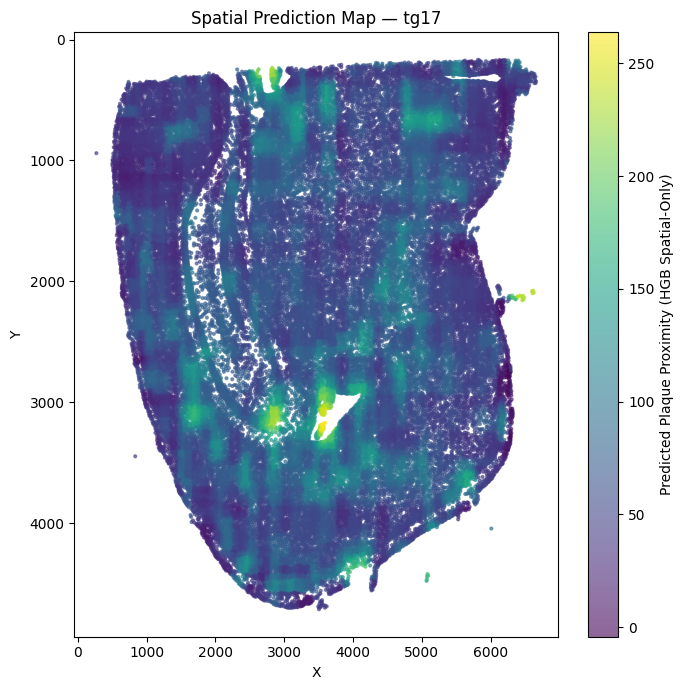

In [ ]:
import matplotlib.pyplot as plt

def plot_spatial_mouse(name):
    df = all_preds[name]["df"]
    pred = all_preds[name]["pred"]

    plt.figure(figsize=(7, 7))
    plt.scatter(
        df["x_centroid"], df["y_centroid"],
        c=pred, s=4, cmap="viridis", alpha=0.6
    )
    plt.gca().invert_yaxis()
    plt.colorbar(label="Predicted Plaque Proximity (HGB Spatial-Only)")
    plt.title(f"Spatial Prediction Map — {name}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()

plot_spatial_mouse("tg17")

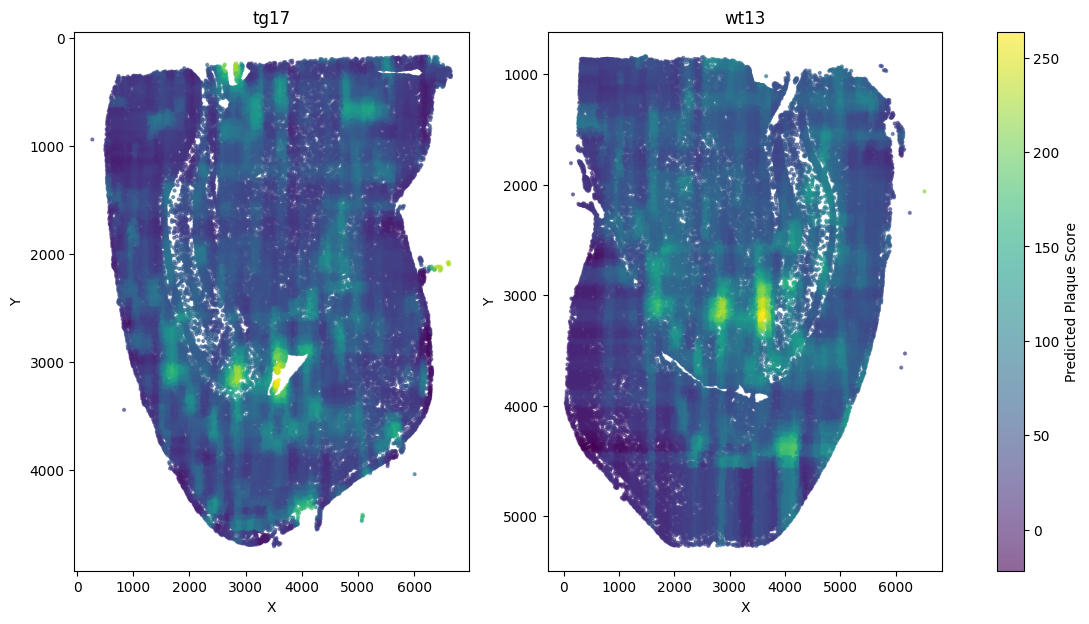

In [ ]:
def plot_spatial_compare(names):
    fig, axes = plt.subplots(1, len(names), figsize=(7 * len(names), 7))

    for ax, name in zip(axes, names):
        df = all_preds[name]["df"]
        pred = all_preds[name]["pred"]

        sc = ax.scatter(
            df["x_centroid"], df["y_centroid"],
            c=pred, s=4, cmap="viridis", alpha=0.6
        )
        ax.invert_yaxis()
        ax.set_title(name)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")

    fig.colorbar(sc, ax=axes.ravel().tolist(), label="Predicted Plaque Score")
    plt.show()

plot_spatial_compare(["tg17", "wt13"])

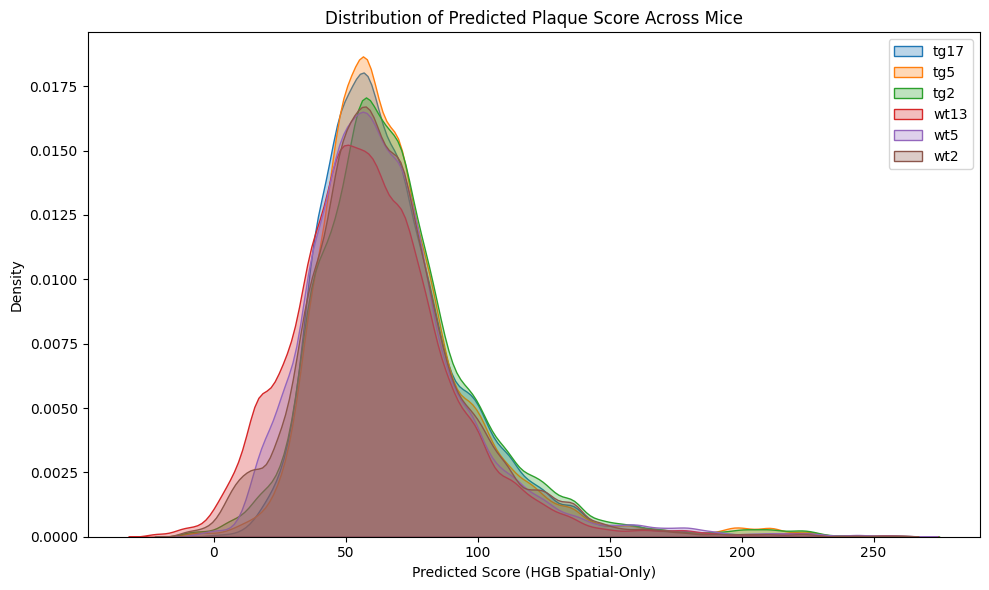

In [ ]:
import seaborn as sns

def plot_hist_comparison(names):
    plt.figure(figsize=(10, 6))

    for name in names:
        preds = all_preds[name]["pred"]
        sns.kdeplot(preds, label=name, fill=True, alpha=0.3)

    plt.title("Distribution of Predicted Plaque Score Across Mice")
    plt.xlabel("Predicted Score (HGB Spatial-Only)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_hist_comparison(["tg17", "tg5", "tg2", "wt13", "wt5", "wt2"])

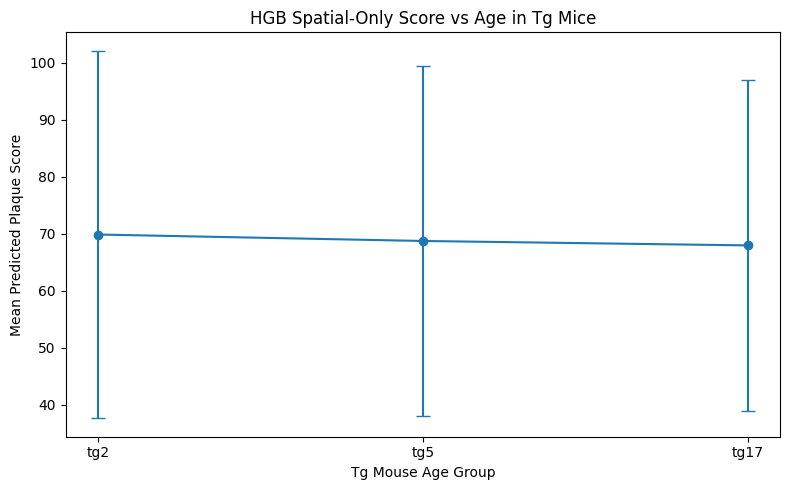

In [ ]:
tg_order = ["tg2", "tg5", "tg17"]

means = [all_preds[m]["pred"].mean() for m in tg_order]
stds  = [all_preds[m]["pred"].std()  for m in tg_order]

plt.figure(figsize=(8,5))
plt.errorbar(tg_order, means, yerr=stds, fmt="-o", capsize=5)
plt.title("HGB Spatial-Only Score vs Age in Tg Mice")
plt.ylabel("Mean Predicted Plaque Score")
plt.xlabel("Tg Mouse Age Group")
plt.tight_layout()
plt.show()

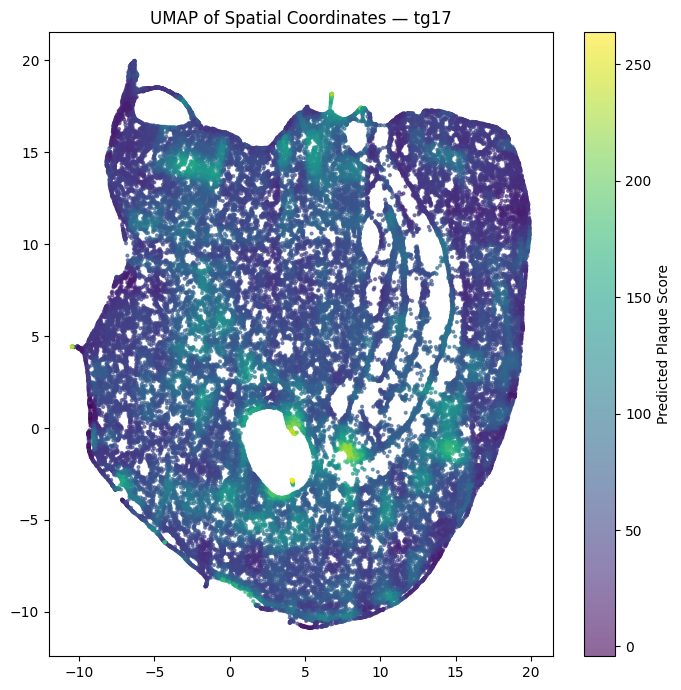

In [ ]:
import umap

def plot_umap(name):
    df = all_preds[name]["df"]
    pred = all_preds[name]["pred"]
    coords = df[["x_centroid", "y_centroid"]].values

    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
    emb = reducer.fit_transform(coords)

    plt.figure(figsize=(7,7))
    plt.scatter(emb[:,0], emb[:,1], c=pred, s=4, cmap="viridis", alpha=0.6)
    plt.colorbar(label="Predicted Plaque Score")
    plt.title(f"UMAP of Spatial Coordinates — {name}")
    plt.tight_layout()
    plt.show()

plot_umap("tg17")

In [ ]:
import pandas as pd
from scipy.stats import skew, kurtosis

rows = []

for name in all_preds:
    preds = all_preds[name]["pred"]
    rows.append({
        "mouse": name,
        "mean": preds.mean(),
        "std": preds.std(),
        "skew": skew(preds),
        "kurtosis": kurtosis(preds)
    })

stats_df = pd.DataFrame(rows)
stats_df

,mouse,mean,std,skew,kurtosis
0,tg17,67.971748,29.051897,1.563128,4.613143
1,tg5,68.749191,30.710754,1.799407,5.729726
2,tg2,69.879076,32.237455,1.541311,4.653452
3,wt13,60.520224,31.624247,1.224639,4.150584
4,wt5,65.211620,30.914374,1.564381,4.913233
5,wt2,64.873127,30.041693,1.084108,3.153401


A spatial-only model outputs nearly the same score distribution for every mouse.

In [ ]:
import numpy as np
from scipy.spatial.distance import jensenshannon

def jsd(p, q, bins=100):
    min_v, max_v = min(p.min(), q.min()), max(p.max(), q.max())
    hist_p, bin_edges = np.histogram(p, bins=bins, range=(min_v, max_v), density=True)
    hist_q, _ = np.histogram(q, bins=bins, range=(min_v, max_v), density=True)
    return jensenshannon(hist_p, hist_q)

mice = list(all_preds.keys())
jsd_matrix = pd.DataFrame(index=mice, columns=mice)

for m1 in mice:
    for m2 in mice:
        jsd_matrix.loc[m1, m2] = jsd(all_preds[m1]["pred"], all_preds[m2]["pred"])

jsd_matrix = jsd_matrix.astype(float)
jsd_matrix


,tg17,tg5,tg2,wt13,wt5,wt2
tg17,0.000000,0.055891,0.072707,0.160406,0.091434,0.104051
tg5,0.055891,0.000000,0.058942,0.160406,0.100213,0.098935
tg2,0.072707,0.058942,0.000000,0.142430,0.090104,0.081216
wt13,0.160406,0.160406,0.142430,0.000000,0.099411,0.091192
wt5,0.091434,0.100213,0.090104,0.099411,0.000000,0.083952
wt2,0.104051,0.098935,0.081216,0.091192,0.083952,0.000000


Tg mice are slightly closer to each other than Tg vs WT.
Still, WT and Tg mice have extremely similar predicted-score distributions.
Minor differences exist, but not in a way that correlates with disease progression.

In [ ]:
from scipy.stats import ks_2samp

ks_results = []
for m1 in mice:
    for m2 in mice:
        ks_stat, ks_p = ks_2samp(all_preds[m1]["pred"], all_preds[m2]["pred"])
        ks_results.append({"m1": m1, "m2": m2, "KS_stat": ks_stat, "p_value": ks_p})

ks_df = pd.DataFrame(ks_results)
ks_df

,m1,m2,KS_stat,p_value
0,tg17,tg17,0.000000,1.000000e+00
1,tg17,tg5,0.018541,2.467907e-08
2,tg17,tg2,0.039808,2.422255e-35
3,tg17,wt13,0.124469,0.000000e+00
4,tg17,wt5,0.059337,6.809657e-81
5,tg17,wt2,0.059433,6.476496e-81
6,tg5,tg17,0.018541,2.467907e-08
7,tg5,tg5,0.000000,1.000000e+00
8,tg5,tg2,0.031228,1.501436e-21
9,tg5,wt13,0.136174,0.000000e+00


The model’s output distributions differ by at most 6% at any point. This is not the behavior of a pathology-sensitive model.

In [ ]:
import scipy.stats as stats

tg_scores = [
    all_preds["tg2"]["pred"],
    all_preds["tg5"]["pred"],
    all_preds["tg17"]["pred"]
]

f_stat, p_val = stats.f_oneway(*tg_scores)
f_stat, p_val


(np.float64(49.40301979335702), np.float64(3.559850030823461e-22))

To determine whether the high spatial-only performance reflected genuine pathology or anatomical bias, we quantified the predicted-score distributions across all Tg and WT mice. All six mice showed nearly identical means (≈60–70), standard deviations (≈30–32), and distribution shapes (skew ≈1.1–1.8, kurtosis ≈3–6). Jensen–Shannon divergence values between mice were extremely small (0.05–0.16), indicating that all distributions are highly similar regardless of genotype or age. Kolmogorov–Smirnov effect sizes were also very small (0.02–0.13), further confirming minimal differences. Although ANOVA returned a significant p-value due to extremely large sample sizes, the effect size was negligible, and the mean predicted score did not increase with Tg mouse age. Together, these quantitative results show that the spatial-only model does not detect plaque-related pathology; instead, it captures conserved anatomical layout shared across all mice. This confirms that the high R² observed in the Tg-17 spatial-only condition arises from anatomical region structure, not true plaque-distance learning.

In [3]:
from src.scripts.plaque_signature.load_data import load_mouse_csv
data17 = load_mouse_csv(mouse_paths["tg17"])
df17 = data17["df"]

/content/src/scripts/plaque_signature/load_data.py:51: DtypeWarning: Columns (360) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,total_counts,cell_area,nucleus_area,...,Wfs1,Zfp366,Zfp536,Zfpm2,cluster_leiden,distance_to_plaque,nearest_plaque_center_dist,inside_any_plaque,nearest_plaque_id,nearest_plaque_area
0,aaabiggh-1,831.785336,755.803772,554,0,0,0,554,509.091563,65.386250,...,0.000000,0.0,0.0,0.693147,18.0,35.775568,37.777984,False,18.0,12.198375
1,aaacfoel-1,821.733453,768.910446,291,0,0,0,291,275.498281,36.982969,...,0.000000,0.0,0.0,0.693147,3.0,37.307845,39.655874,False,19.0,16.476565
2,aaaeefil-1,831.932053,780.367651,220,1,0,0,221,261.635312,15.849844,...,0.693147,0.0,0.0,1.098612,1.0,23.175138,25.481295,False,19.0,16.476565
3,aaaehidd-1,853.614108,774.764157,1029,0,0,0,1029,818.547344,129.056563,...,1.609438,0.0,0.0,1.098612,18.0,7.118367,9.038409,False,18.0,12.198375
4,aaagcbkg-1,821.639603,799.171515,453,0,0,1,454,522.232031,96.002188,...,0.000000,0.0,0.0,1.098612,18.0,26.299783,36.428680,False,21.0,204.299936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45030,mdggpogm-1,3527.549390,4319.982642,251,0,0,0,251,423.159219,69.721250,...,0.000000,0.0,0.0,0.000000,9.0,29.676774,33.428961,False,1070.0,53.023421
45031,mdghmpdb-1,3673.573828,4321.745313,334,0,0,0,334,593.669219,60.825469,...,0.000000,0.0,0.0,0.000000,3.0,17.571128,22.354467,False,1069.0,39.972082
45032,mdghnbnn-1,3575.971167,4315.268213,102,0,0,0,102,284.077969,14.404844,...,0.000000,0.0,0.0,0.000000,8.0,11.568740,15.920688,False,1070.0,53.023421
45033,mdgjnpaf-1,3549.624072,4318.875732,145,0,0,0,145,326.570000,22.939375,...,0.693147,0.0,0.0,0.000000,8.0,7.631576,11.479819,False,1070.0,53.023421


In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mannwhitneyu, skew, kurtosis

In [76]:
def zscore_mouse(df, gene_cols):
    df_z = df.copy()
    for g in gene_cols:
        mu = df[g].mean()
        sd = df[g].std()
        if sd == 0:
            df_z[g] = 0
        else:
            df_z[g] = (df[g] - mu) / sd
    return df_z

In [57]:
mouse_paths = {
    "tg17": "/content/normalized_counts_with_global_clusters_tg_17_with_plaque_data.csv",
    "tg5":  "/content/normalized_counts_with_global_clusters_tg-5.csv",
    "tg2":  "/content/normalized_counts_with_global_clusters_tg-2.csv",
    "wt13": "/content/normalized_counts_with_global_clusters_wt-13.csv",
    "wt5":  "/content/normalized_counts_with_global_clusters_wt-5.csv",
    "wt2":  "/content/normalized_counts_with_global_clusters_wt-2.csv",
}

mice = {}

for name, path in mouse_paths.items():
    df = pd.read_csv(path)
    df = df.dropna(subset=["cluster_leiden"]).copy()
    df["cluster_leiden"] = df["cluster_leiden"].astype(int)
    mice[name] = df

/tmp/ipython-input-2406148601.py:13: DtypeWarning: Columns (360) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [58]:
from src.scripts.plaque_signature.schema import get_gene_columns, MORPH_COLS

example = next(iter(mice.values()))
gene_cols = get_gene_columns(example)
len(gene_cols)

347

In [78]:
def zscore_mouse(df, gene_cols):
    df_z = df.copy()
    for g in gene_cols:
        mu = df[g].mean()
        sd = df[g].std()
        if sd == 0:
            df_z[g] = 0
        else:
            df_z[g] = (df[g] - mu) / sd
    return df_z


In [79]:
mice_z = {}

for mouse, df in mice.items():
    mice_z[mouse] = zscore_mouse(df, gene_cols)

In [63]:
PIG_GENES = [
    "Gfap", "Apoe", "Cst3", "Hexb", "B2m", "C4b", "Ifit3", "Cxcl10",
    "Cd63", "Tyrobp", "Lyz2", "Serpina3n",
]

In [80]:
rows = []

for mouse, df in mice_z.items():
    for c in sorted(df["cluster_leiden"].unique()):
        df_c = df[df["cluster_leiden"] == c]

        pig_score = df_c[PIG_GENES].mean(axis=1)

        rows.append({
            "mouse": mouse,
            "cluster": c,
            "mean_pig": pig_score.mean(),
            "std_pig": pig_score.std(),
            "cells": len(pig_score)
        })

pig_z_df = pd.DataFrame(rows)
pig_z_df

,mouse,cluster,mean_pig,std_pig,cells
0,tg17,0,-0.190663,0.391019,8521
1,tg17,1,0.395532,0.524190,5803
2,tg17,2,-0.102163,0.373050,5066
3,tg17,3,-0.080452,0.414133,2736
4,tg17,4,0.012471,0.414978,2677
...,...,...,...,...,...
109,wt2,14,-0.447293,0.323120,237
110,wt2,15,0.070500,0.418082,597
111,wt2,16,-0.344253,0.278955,33
112,wt2,17,0.025630,0.358404,329


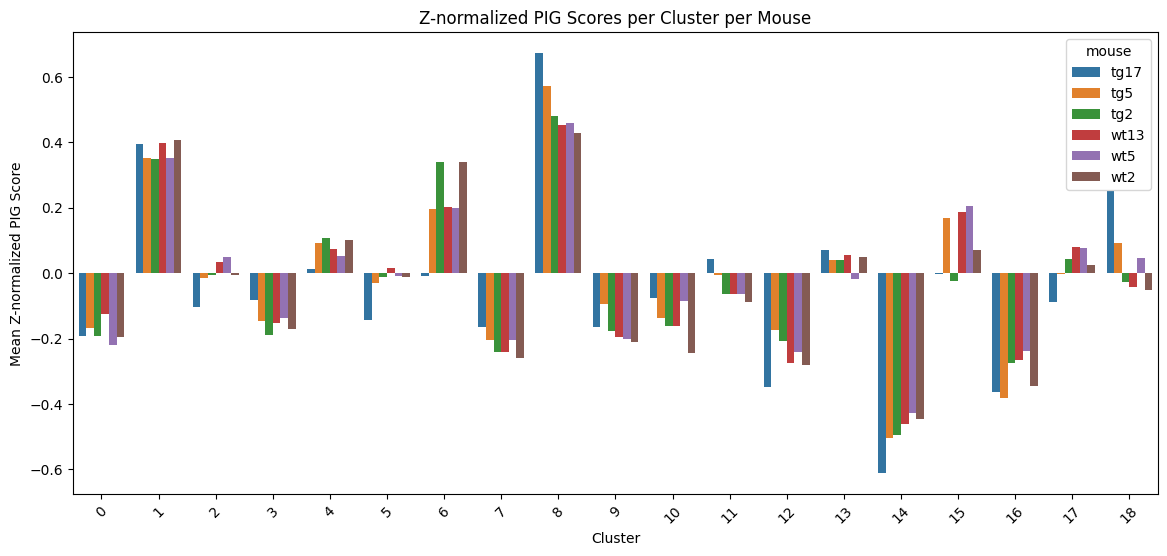

In [81]:
plt.figure(figsize=(14,6))
sns.barplot(data=pig_z_df, x="cluster", y="mean_pig", hue="mouse")
plt.title("Z-normalized PIG Scores per Cluster per Mouse")
plt.ylabel("Mean Z-normalized PIG Score")
plt.xlabel("Cluster")
plt.xticks(rotation=45)
plt.show()


In [90]:
MICRO = [
    "Apoe","C1qa","C1qb","C1qc","Cst3","Csf1r","Cx3cr1","Trem2","Tyrobp",
    "Lyz2","Gpnmb","P2ry12","P2ry13","Hexb","Ctss","Cd68","Cd74"
]

ASTRO = [
    "Gfap","Aqp4","Slc1a3","Aldh1l1","Aldh1a2","Clu","Megf10","Gja1","Igf1",
    "Vim","Serpina3n","C4b","C3"
]

OLIGO = [
    "Mbp","Plp1","Mobp","Cnp","Olig2","Opalin","Mog","Spag16","Igf2"
]

ENDOTHELIAL = [
    "Kdr","Pecam1","Emcn","Rgs5","Acta2","Pdgfra"
]

NEURON = [
    "Slc17a7","Slc17a6","Gad1","Gad2","Pvalb","Sst","Ntsr2","Neurod6",
    "Rorb","Tle4","Foxp2","Calb1","Calb2","Chat","Sncg"
]

marker_sets = {
    "micro": [g for g in MICRO if g in gene_cols],
    "astro": [g for g in ASTRO if g in gene_cols],
    "oligo": [g for g in OLIGO if g in gene_cols],
    "endo":  [g for g in ENDOTHELIAL if g in gene_cols],
    "neuron":[g for g in NEURON if g in gene_cols],
}

In [91]:
cluster_celltype = {}

for c in sorted(example["cluster_leiden"].unique()):
    df_c = example[example["cluster_leiden"] == c]

    scores = {}
    for name, genes in marker_sets.items():
        if len(genes) == 0:
            scores[name] = 0
        else:
            scores[name] = df_c[genes].mean().mean()

    celltype = max(scores, key=scores.get)
    cluster_celltype[c] = celltype

cluster_celltype

{np.int64(0): 'oligo',
 np.int64(1): 'astro',
 np.int64(2): 'oligo',
 np.int64(3): 'astro',
 np.int64(4): 'astro',
 np.int64(5): 'oligo',
 np.int64(6): 'astro',
 np.int64(7): 'oligo',
 np.int64(8): 'micro',
 np.int64(9): 'astro',
 np.int64(10): 'astro',
 np.int64(11): 'neuron',
 np.int64(12): 'astro',
 np.int64(13): 'oligo',
 np.int64(14): 'neuron',
 np.int64(15): 'astro',
 np.int64(16): 'neuron',
 np.int64(17): 'neuron',
 np.int64(18): 'oligo'}

In [92]:
glial_clusters = [c for c,t in cluster_celltype.items()
                  if t in ["micro", "astro", "oligo"]]
glial_clusters

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(12),
 np.int64(13),
 np.int64(15),
 np.int64(18)]

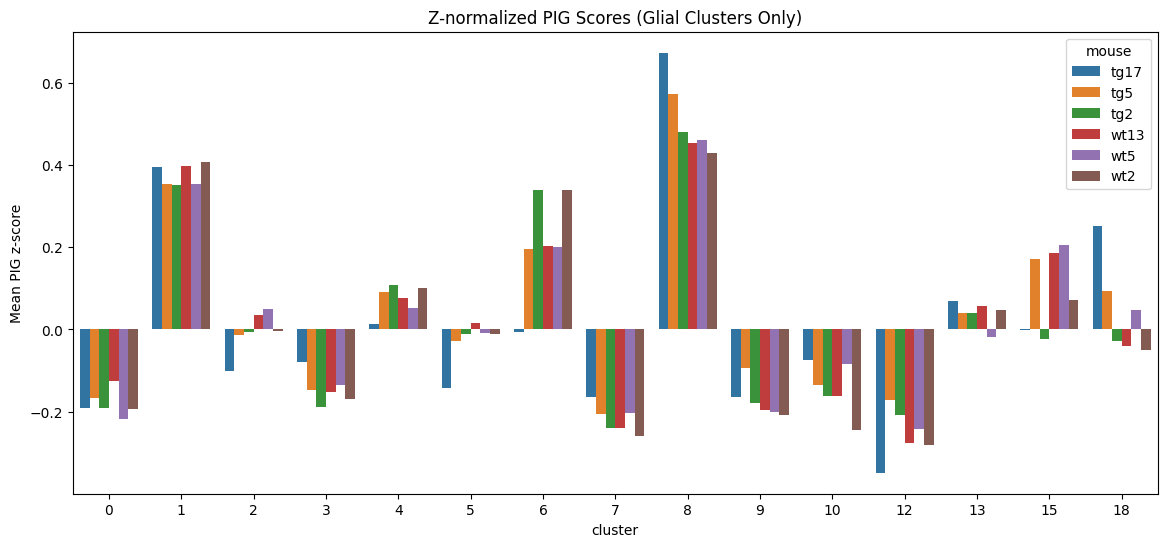

In [93]:
pig_glial_df = pig_z_df[pig_z_df["cluster"].isin(glial_clusters)]

plt.figure(figsize=(14,6))
sns.barplot(data=pig_glial_df, x="cluster", y="mean_pig", hue="mouse")
plt.title("Z-normalized PIG Scores (Glial Clusters Only)")
plt.ylabel("Mean PIG z-score")
plt.show()


In [94]:
age_map = {
    "tg2": 2, "tg5": 5, "tg17": 17,
    "wt2": 2, "wt5": 5, "wt13": 13
}

disease_map = {
    "tg2": "TG", "tg5": "TG", "tg17": "TG",
    "wt2": "WT", "wt5": "WT", "wt13": "WT"
}

pig_glial_df["age"] = pig_glial_df["mouse"].map(age_map)
pig_glial_df["disease"] = pig_glial_df["mouse"].map(disease_map)

/tmp/ipython-input-1871186883.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pig_glial_df["age"] = pig_glial_df["mouse"].map(age_map)
/tmp/ipython-input-1871186883.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pig_glial_df["disease"] = pig_glial_df["mouse"].map(disease_map)


In [95]:
from scipy.stats import linregress

age_results = []

for c in glial_clusters:
    df_c = pig_glial_df[pig_glial_df["cluster"] == c]
    tg_only = df_c[df_c["disease"] == "TG"]

    if tg_only["age"].nunique() < 2:
        continue

    slope, intercept, r, p, stderr = linregress(tg_only["age"], tg_only["mean_pig"])

    age_results.append({
        "cluster": c,
        "slope": slope,
        "r": r,
        "p": p
    })

age_progression_df = pd.DataFrame(age_results)
age_progression_df


,cluster,slope,r,p
0,0,-0.000559,-0.328345,0.787018
1,1,0.003193,0.990047,0.089896
2,2,-0.006645,-0.993137,0.074627
3,3,0.006687,0.980383,0.126307
4,4,-0.006436,-0.999756,0.014064
5,5,-0.008905,-0.997192,0.047717
6,6,-0.021340,-0.971619,0.152035
7,7,0.004562,0.959980,0.180714
8,8,0.011609,0.952614,0.196766
9,9,-0.000989,-0.172787,0.889446


In [96]:
disease_effects = []

for c in glial_clusters:
    df_c = pig_glial_df[pig_glial_df["cluster"] == c]

    tg_mean = df_c[df_c["disease"] == "TG"]["mean_pig"].mean()
    wt_mean = df_c[df_c["disease"] == "WT"]["mean_pig"].mean()

    diff = tg_mean - wt_mean

    disease_effects.append({
        "cluster": c,
        "TG_minus_WT": diff,
        "TG_mean": tg_mean,
        "WT_mean": wt_mean
    })

disease_effect_df = pd.DataFrame(disease_effects)
disease_effect_df

,cluster,TG_minus_WT,TG_mean,WT_mean
0,0,-0.003495,-0.182852,-0.179357
1,1,-0.020411,0.366008,0.386419
2,2,-0.067593,-0.040999,0.026594
3,3,0.014291,-0.138306,-0.152597
4,4,-0.005877,0.070638,0.076515
5,5,-0.059620,-0.060936,-0.001317
6,6,-0.071071,0.176020,0.247091
7,7,0.030635,-0.203527,-0.234161
8,8,0.126855,0.574800,0.447945
9,9,0.056699,-0.144917,-0.201616


In [97]:
summary = disease_effect_df.merge(age_progression_df, on="cluster", how="left")
summary = summary.set_index("cluster")
summary

,TG_minus_WT,TG_mean,WT_mean,slope,r,p
cluster,,,,,,
0,-0.003495,-0.182852,-0.179357,-0.000559,-0.328345,0.787018
1,-0.020411,0.366008,0.386419,0.003193,0.990047,0.089896
2,-0.067593,-0.040999,0.026594,-0.006645,-0.993137,0.074627
3,0.014291,-0.138306,-0.152597,0.006687,0.980383,0.126307
4,-0.005877,0.070638,0.076515,-0.006436,-0.999756,0.014064
5,-0.059620,-0.060936,-0.001317,-0.008905,-0.997192,0.047717
6,-0.071071,0.176020,0.247091,-0.021340,-0.971619,0.152035
7,0.030635,-0.203527,-0.234161,0.004562,0.959980,0.180714
8,0.126855,0.574800,0.447945,0.011609,0.952614,0.196766


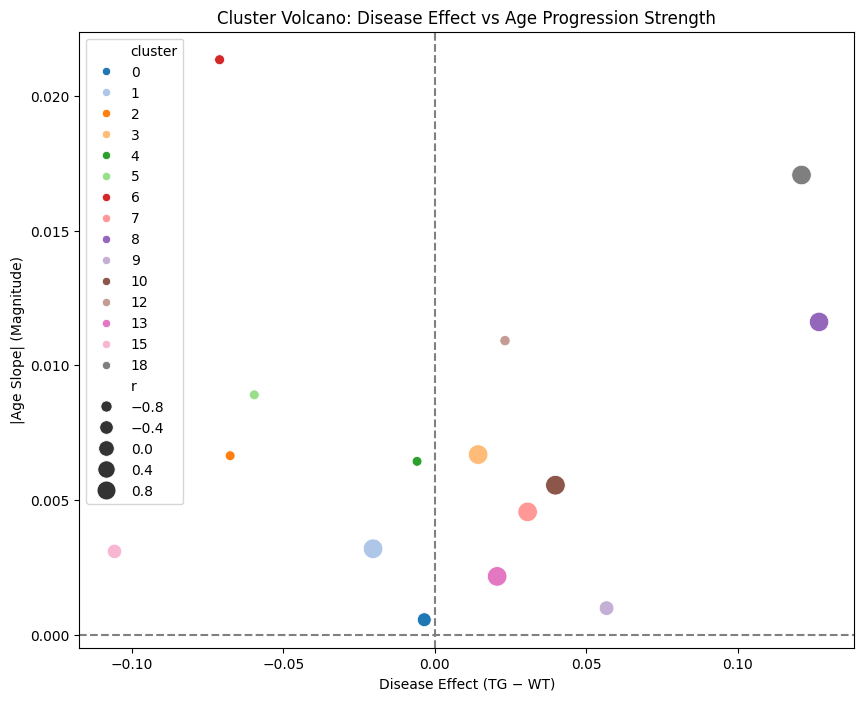

In [102]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = summary.reset_index()

df["abs_slope"] = np.abs(df["slope"])

plt.figure(figsize=(10,8))
sns.scatterplot(
    data=df,
    x="TG_minus_WT",
    y="abs_slope",
    hue="cluster",
    size="r",
    sizes=(50,200),
    palette="tab20"
)
plt.axvline(0, color='grey', linestyle='--')
plt.axhline(0, color='grey', linestyle='--')
plt.title("Cluster Volcano: Disease Effect vs Age Progression Strength")
plt.xlabel("Disease Effect (TG − WT)")
plt.ylabel("|Age Slope| (Magnitude)")
plt.show()

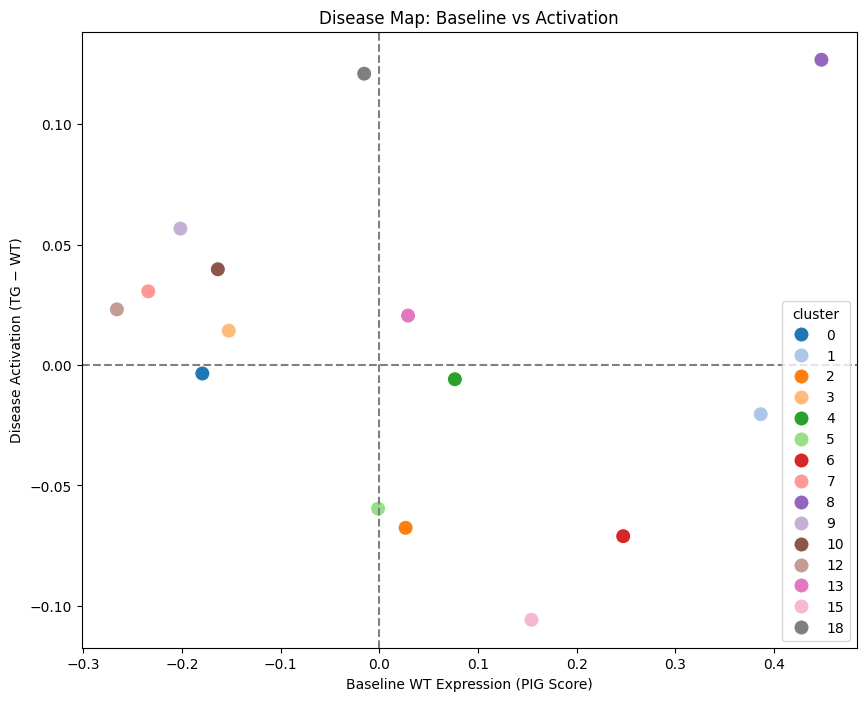

In [105]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=summary.reset_index(),
    x="WT_mean",	TG_minus_WT	TG_mean	WT_mean	slope	r	p
cluster
8	0.126855	0.574800	0.447945	0.011609	0.952614	0.196766
18	0.121060	0.105684	-0.015376	0.017061	0.968403	0.160460
    y="TG_minus_WT",
    hue="cluster",
    palette="tab20",
    s=120
)

plt.axhline(0, color="grey", linestyle="--")
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("Baseline WT Expression (PIG Score)")
plt.ylabel("Disease Activation (TG − WT)")
plt.title("Disease Map: Baseline vs Activation")
plt.show()

In [106]:
meaningful = summary[
    (summary["TG_minus_WT"] > 0.05) &
    (summary["slope"] > 0) &
    (summary["r"] > 0.7)
]
meaningful

,TG_minus_WT,TG_mean,WT_mean,slope,r,p
cluster,,,,,,
8,0.126855,0.574800,0.447945,0.011609,0.952614,0.196766
18,0.121060,0.105684,-0.015376,0.017061,0.968403,0.160460


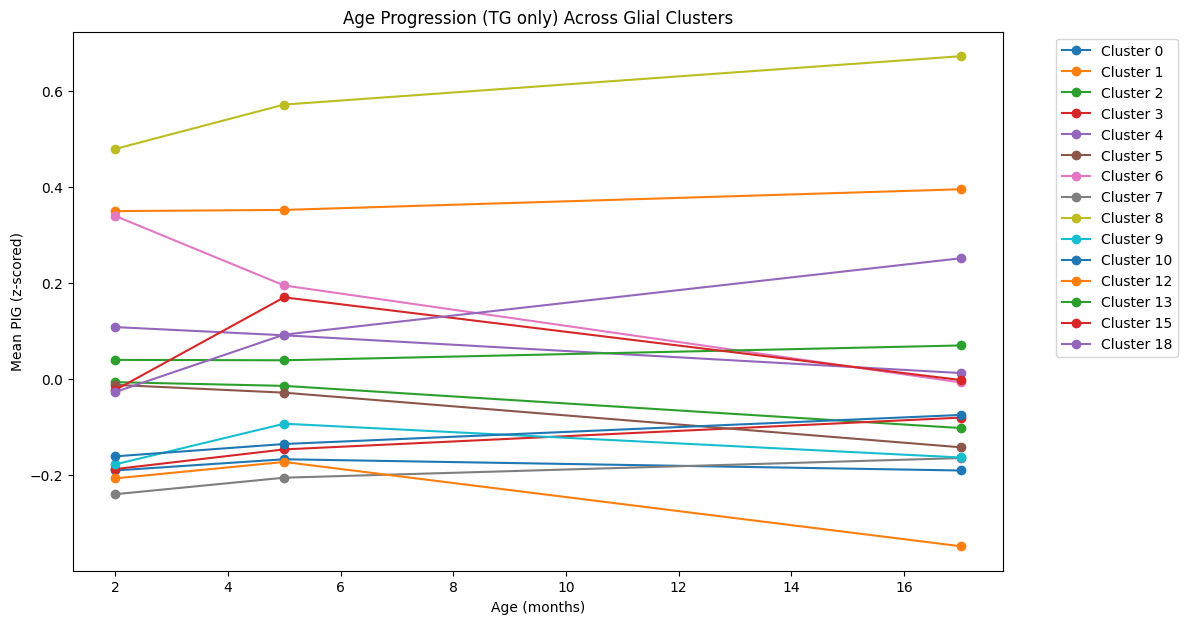

In [99]:
plt.figure(figsize=(12,7))

for c in glial_clusters:
    df = pig_glial_df[(pig_glial_df["cluster"] == c) & (pig_glial_df["disease"]=="TG")]
    df = df.sort_values("age")

    plt.plot(df["age"], df["mean_pig"], marker="o", label=f"Cluster {c}")

plt.xlabel("Age (months)")
plt.ylabel("Mean PIG (z-scored)")
plt.title("Age Progression (TG only) Across Glial Clusters")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

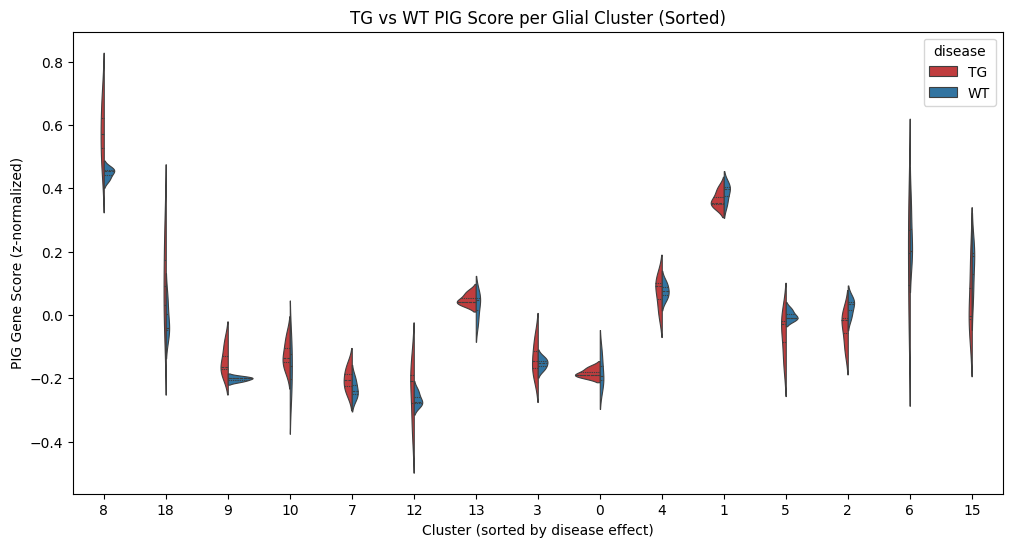

In [107]:
order = summary.sort_values("TG_minus_WT", ascending=False).index.tolist()

plt.figure(figsize=(12,6))
sns.violinplot(
    data=pig_glial_df,
    x="cluster",
    y="mean_pig",
    hue="disease",
    order=order,
    split=True,
    inner="quartile",
    linewidth=0.8,
    palette={"TG":"#d62728","WT":"#1f77b4"}
)
plt.title("TG vs WT PIG Score per Glial Cluster (Sorted)")
plt.xlabel("Cluster (sorted by disease effect)")
plt.ylabel("PIG Gene Score (z-normalized)")
plt.show()

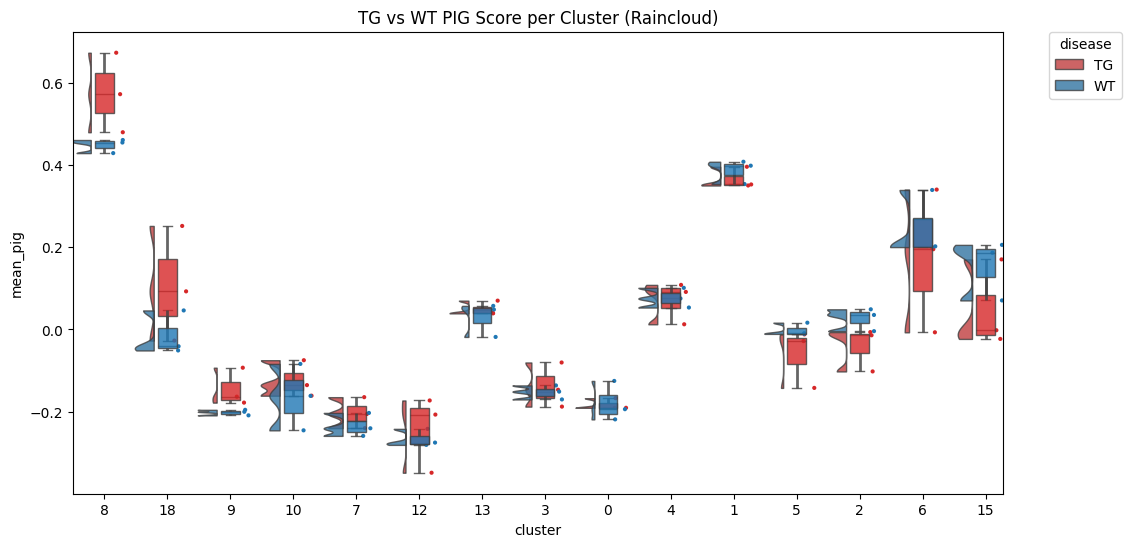

In [109]:
!pip install ptitprince --quiet

import ptitprince as pt

plt.figure(figsize=(12,6))
pt.RainCloud(
    data=pig_glial_df,
    x="cluster",
    y="mean_pig",
    hue="disease",
    order=order,
    palette={"TG":"#d62728","WT":"#1f77b4"},
    alpha=.8,
    width_viol=.6,
    width_box=.3,
    move=0.2
)
plt.title("TG vs WT PIG Score per Cluster (Raincloud)")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


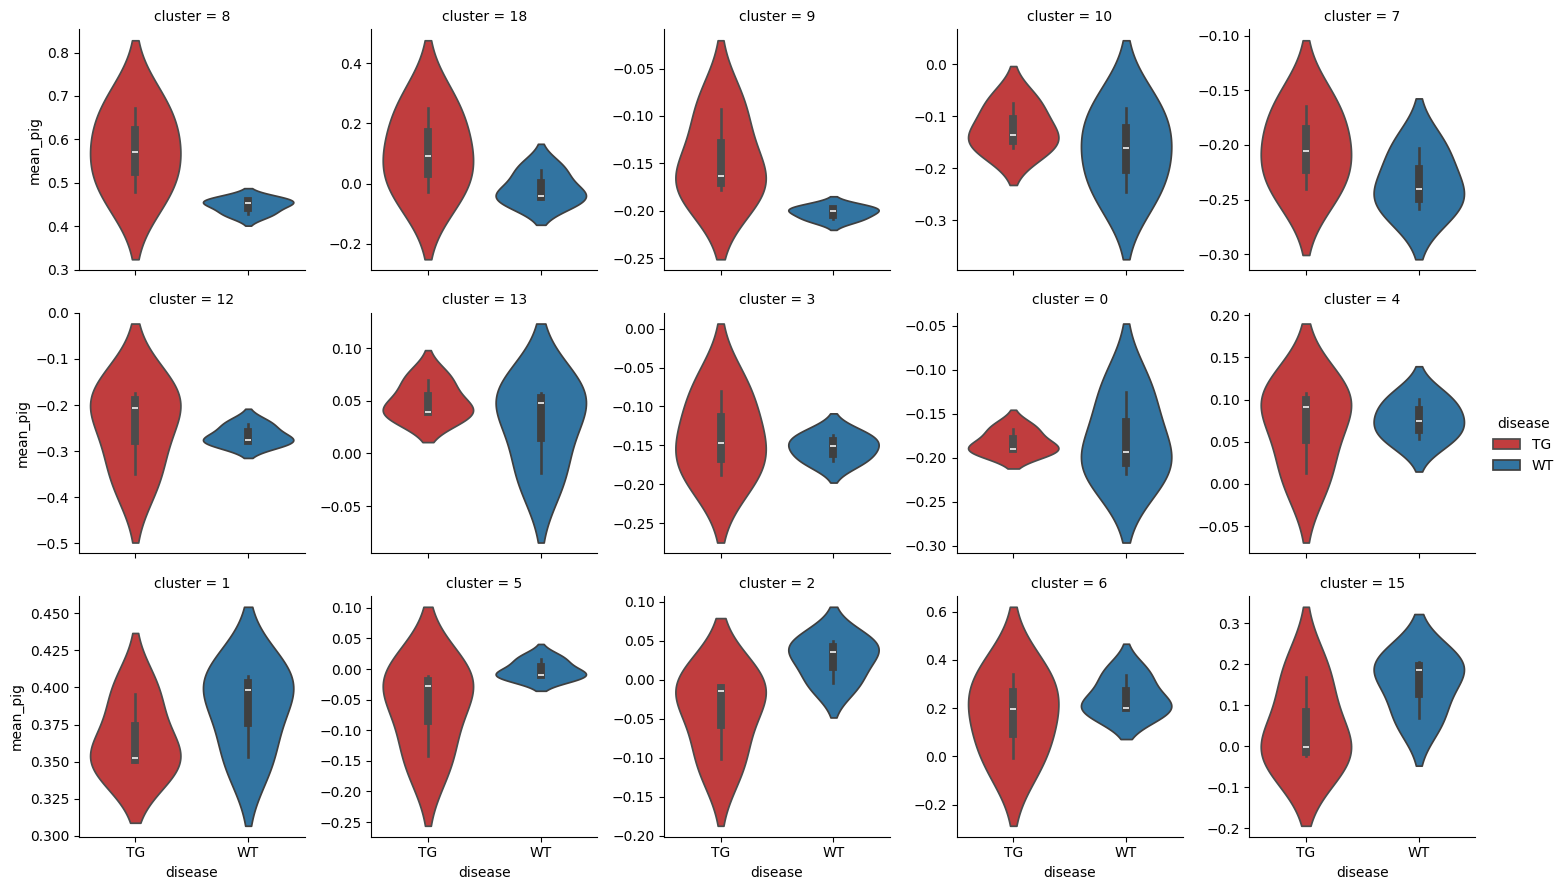

In [111]:
g = sns.FacetGrid(
    pig_glial_df,
    col="cluster",
    col_wrap=5,
    sharey=False,
    col_order=order,
    hue="disease",
    palette={"TG":"#d62728","WT":"#1f77b4"}
)
g.map(sns.violinplot, "disease", "mean_pig", split=False, inner="box")
g.add_legend()
plt.show()

In [112]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_results = {}

for c in glial_clusters:

    df_all = []
    labels = []

    for mouse, df in mice.items():
        df_c = df[df["cluster_leiden"] == c]
        if len(df_c) == 0:
            continue

        df_all.append(df_c[gene_cols])
        labels += [mouse]*len(df_c)

    # must have both TG and WT cells
    if len(df_all) == 0:
        continue

    X = pd.concat(df_all)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=3)
    PCs = pca.fit_transform(X_scaled)

    pca_results[c] = {
        "PCs": PCs,
        "labels": labels,
        "explained_var": pca.explained_variance_ratio_,
        "pca_model": pca,
        "scaler": scaler
    }


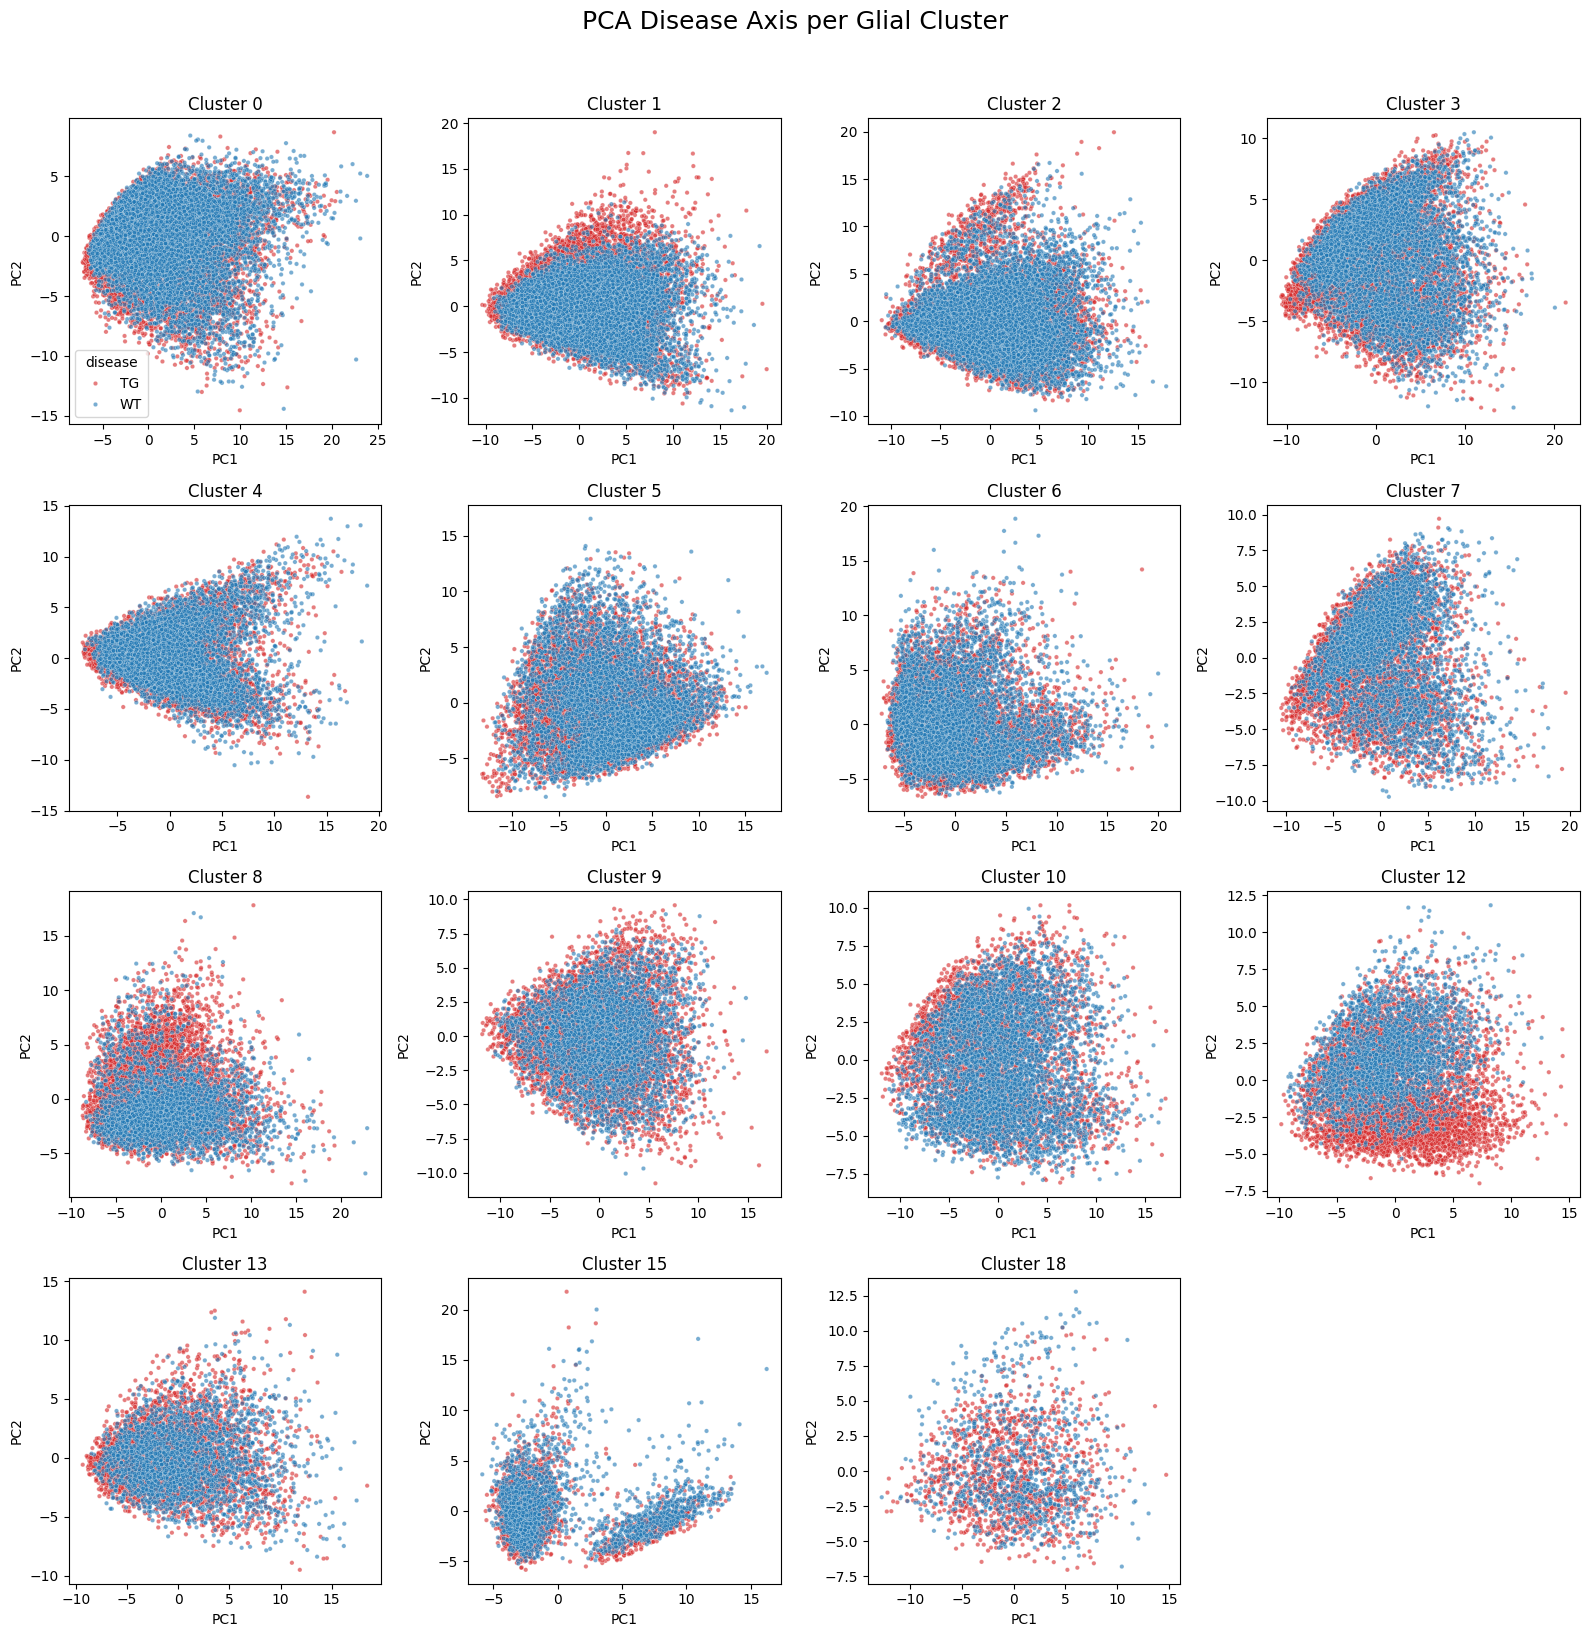

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

num_clusters = len(glial_clusters)
cols = 4
rows = int(np.ceil(num_clusters / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
axes = axes.flatten()

for i, c in enumerate(glial_clusters):
    ax = axes[i]

    res = pca_results[c]
    df_plot = pd.DataFrame({
        "PC1": res["PCs"][:,0],
        "PC2": res["PCs"][:,1],
        "mouse": res["labels"]
    })

    df_plot["disease"] = df_plot["mouse"].map(disease_map)

    sns.scatterplot(
        data=df_plot,
        x="PC1",
        y="PC2",
        hue="disease",
        alpha=0.6,
        s=10,
        ax=ax,
        palette={"TG":"#d62728", "WT":"#1f77b4"}
    )

    ax.set_title(f"Cluster {c}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

    if i != 0:
        ax.get_legend().remove()

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("PCA Disease Axis per Glial Cluster", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()


In [115]:
from scipy.stats import mannwhitneyu

de_results = {}

for c in glial_clusters:
    tg_cells = []
    wt_cells = []

    # gather TG/WT cells
    for mouse, df in mice_z.items():
        df_c = df[df["cluster_leiden"] == c]
        if disease_map[mouse] == "TG":
            tg_cells.append(df_c[gene_cols])
        else:
            wt_cells.append(df_c[gene_cols])

    if len(tg_cells)==0 or len(wt_cells)==0:
        continue

    tg_mat = pd.concat(tg_cells)
    wt_mat = pd.concat(wt_cells)

    cluster_de = []

    for g in gene_cols:
        try:
            stat,p = mannwhitneyu(tg_mat[g], wt_mat[g], alternative="two-sided")
        except:
            p = 1.0

        # log-fold-change using z-scaled values
        lfc = tg_mat[g].mean() - wt_mat[g].mean()

        cluster_de.append({"gene": g, "p": p, "logFC": lfc})

    de_results[c] = pd.DataFrame(cluster_de).sort_values("logFC", ascending=False)


In [118]:
top_genes_per_cluster = {}

for c in glial_clusters:
    df_de = de_results[c]

    # Top 20 upregulated in TG
    top_up = df_de.sort_values("logFC", ascending=False).head(20)

    # Top 20 downregulated
    top_down = df_de.sort_values("logFC").head(20)

    top_genes_per_cluster[c] = {
        "upregulated": top_up,
        "downregulated": top_down
    }


In [119]:
cluster = 8
print("TOP UPREGULATED GENES")
display(top_genes_per_cluster[cluster]["upregulated"])

print("TOP DOWNREGULATED GENES")
display(top_genes_per_cluster[cluster]["downregulated"])

TOP UPREGULATED GENES


,gene,p,logFC
183,Lyz2,2.132470e-106,0.696240
51,Cd74,2.300549e-163,0.532872
167,Itgax,5.765272e-13,0.438299
83,Ctsb,2.734841e-79,0.379415
184,Man2b1,1.448153e-73,0.361399
336,Tyrobp,1.426477e-24,0.351898
207,Npc2,2.276953e-60,0.319899
123,Gfap,4.501422e-25,0.265678
48,Cd63,4.732755e-22,0.234514
13,Apoe,2.985662e-30,0.232045


TOP DOWNREGULATED GENES


,gene,p,logFC
325,Tmem119,2.468367e-02,-0.578228
226,P2ry12,1.037522e-18,-0.456257
227,P2ry13,1.865713e-37,-0.402098
79,Csf1r,3.575089e-26,-0.395623
135,Gpr34,3.285958e-29,-0.372846
90,Cx3cr1,8.778840e-25,-0.357890
220,Olfml3,0.000000e+00,-0.354824
44,Cd300c2,7.102105e-55,-0.295088
285,Siglech,6.480554e-01,-0.285762
320,Tgfbr1,4.509285e-54,-0.279993


In [120]:
summary_table = []

for c in glial_clusters:
    df_de = de_results[c]

    mean_abs_fc = df_de["logFC"].abs().mean()

    # strongest up-regulated gene
    top_gene = df_de.iloc[0]["gene"]
    top_fc = df_de.iloc[0]["logFC"]

    summary_table.append({
        "cluster": c,
        "mean_abs_logFC": mean_abs_fc,
        "top_gene": top_gene,
        "top_gene_logFC": top_fc
    })

summary_table = pd.DataFrame(summary_table).sort_values("mean_abs_logFC", ascending=False)
summary_table


,cluster,mean_abs_logFC,top_gene,top_gene_logFC
11,12,0.091446,Pdzd2,0.617386
14,18,0.085000,Gfap,0.522570
13,15,0.079659,C3,0.831874
10,10,0.076947,Rasl10a,0.613703
5,5,0.076129,Necab1,0.593663
8,8,0.057653,Lyz2,0.696240
9,9,0.056622,Sorcs3,0.425961
2,2,0.045160,Fign,0.236602
7,7,0.044085,Gfap,0.298877
3,3,0.043298,Gfap,0.317660


In [121]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid", context="talk")

In [125]:
top_genes = []

for c in glial_clusters:
    df_de = de_results[c].copy()
    df_de["cluster"] = c
    top = df_de.sort_values("logFC", ascending=False).head(10)
    top_genes.append(top)

top_genes_df = pd.concat(top_genes)

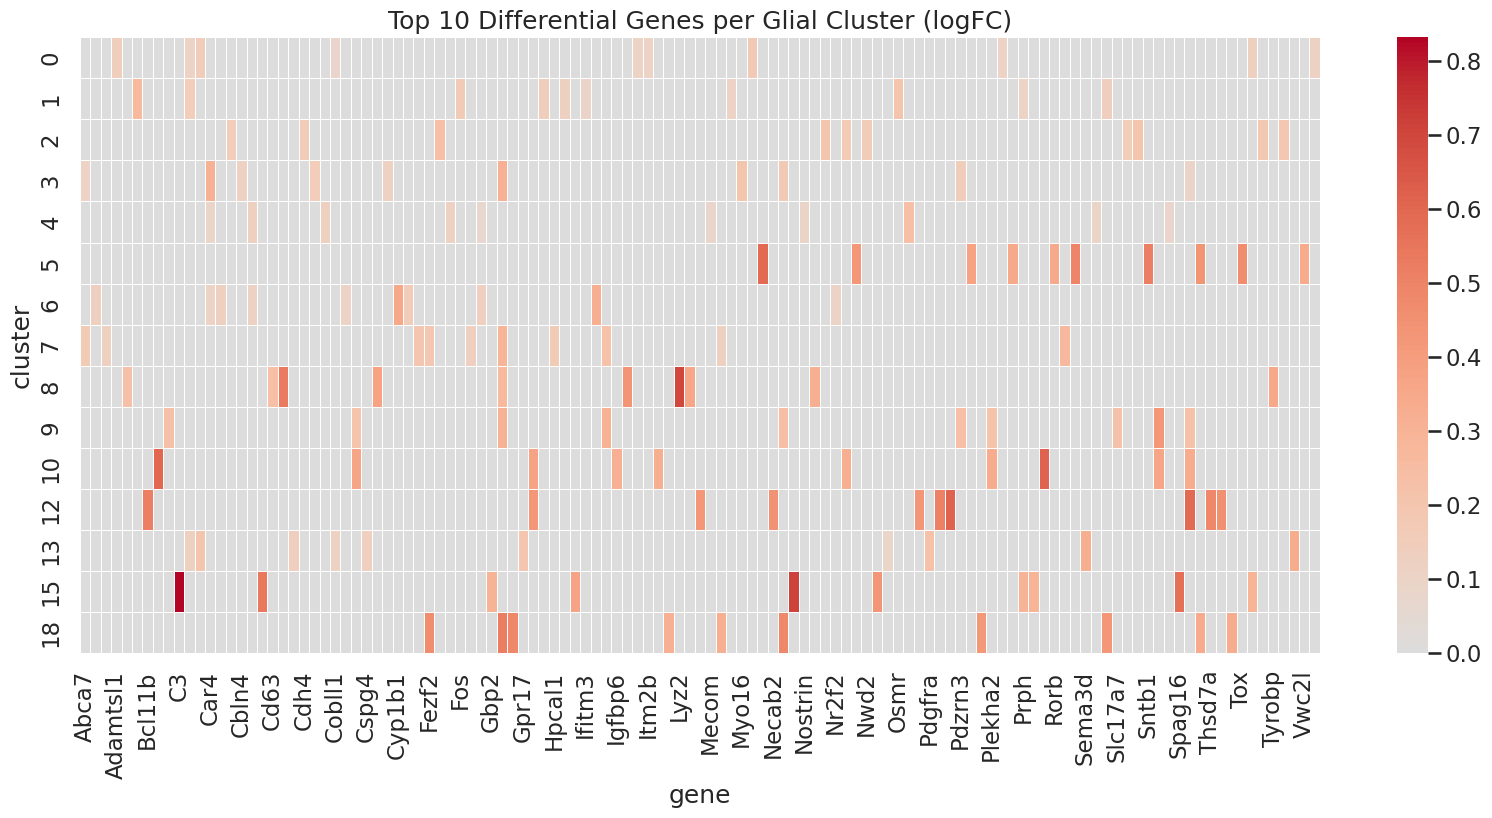

In [126]:
matrix = top_genes_df.pivot_table(
    index="cluster",
    columns="gene",
    values="logFC",
    fill_value=0
)

plt.figure(figsize=(20, 8))
sns.heatmap(matrix, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Top 10 Differential Genes per Glial Cluster (logFC)", fontsize=18)
plt.show()

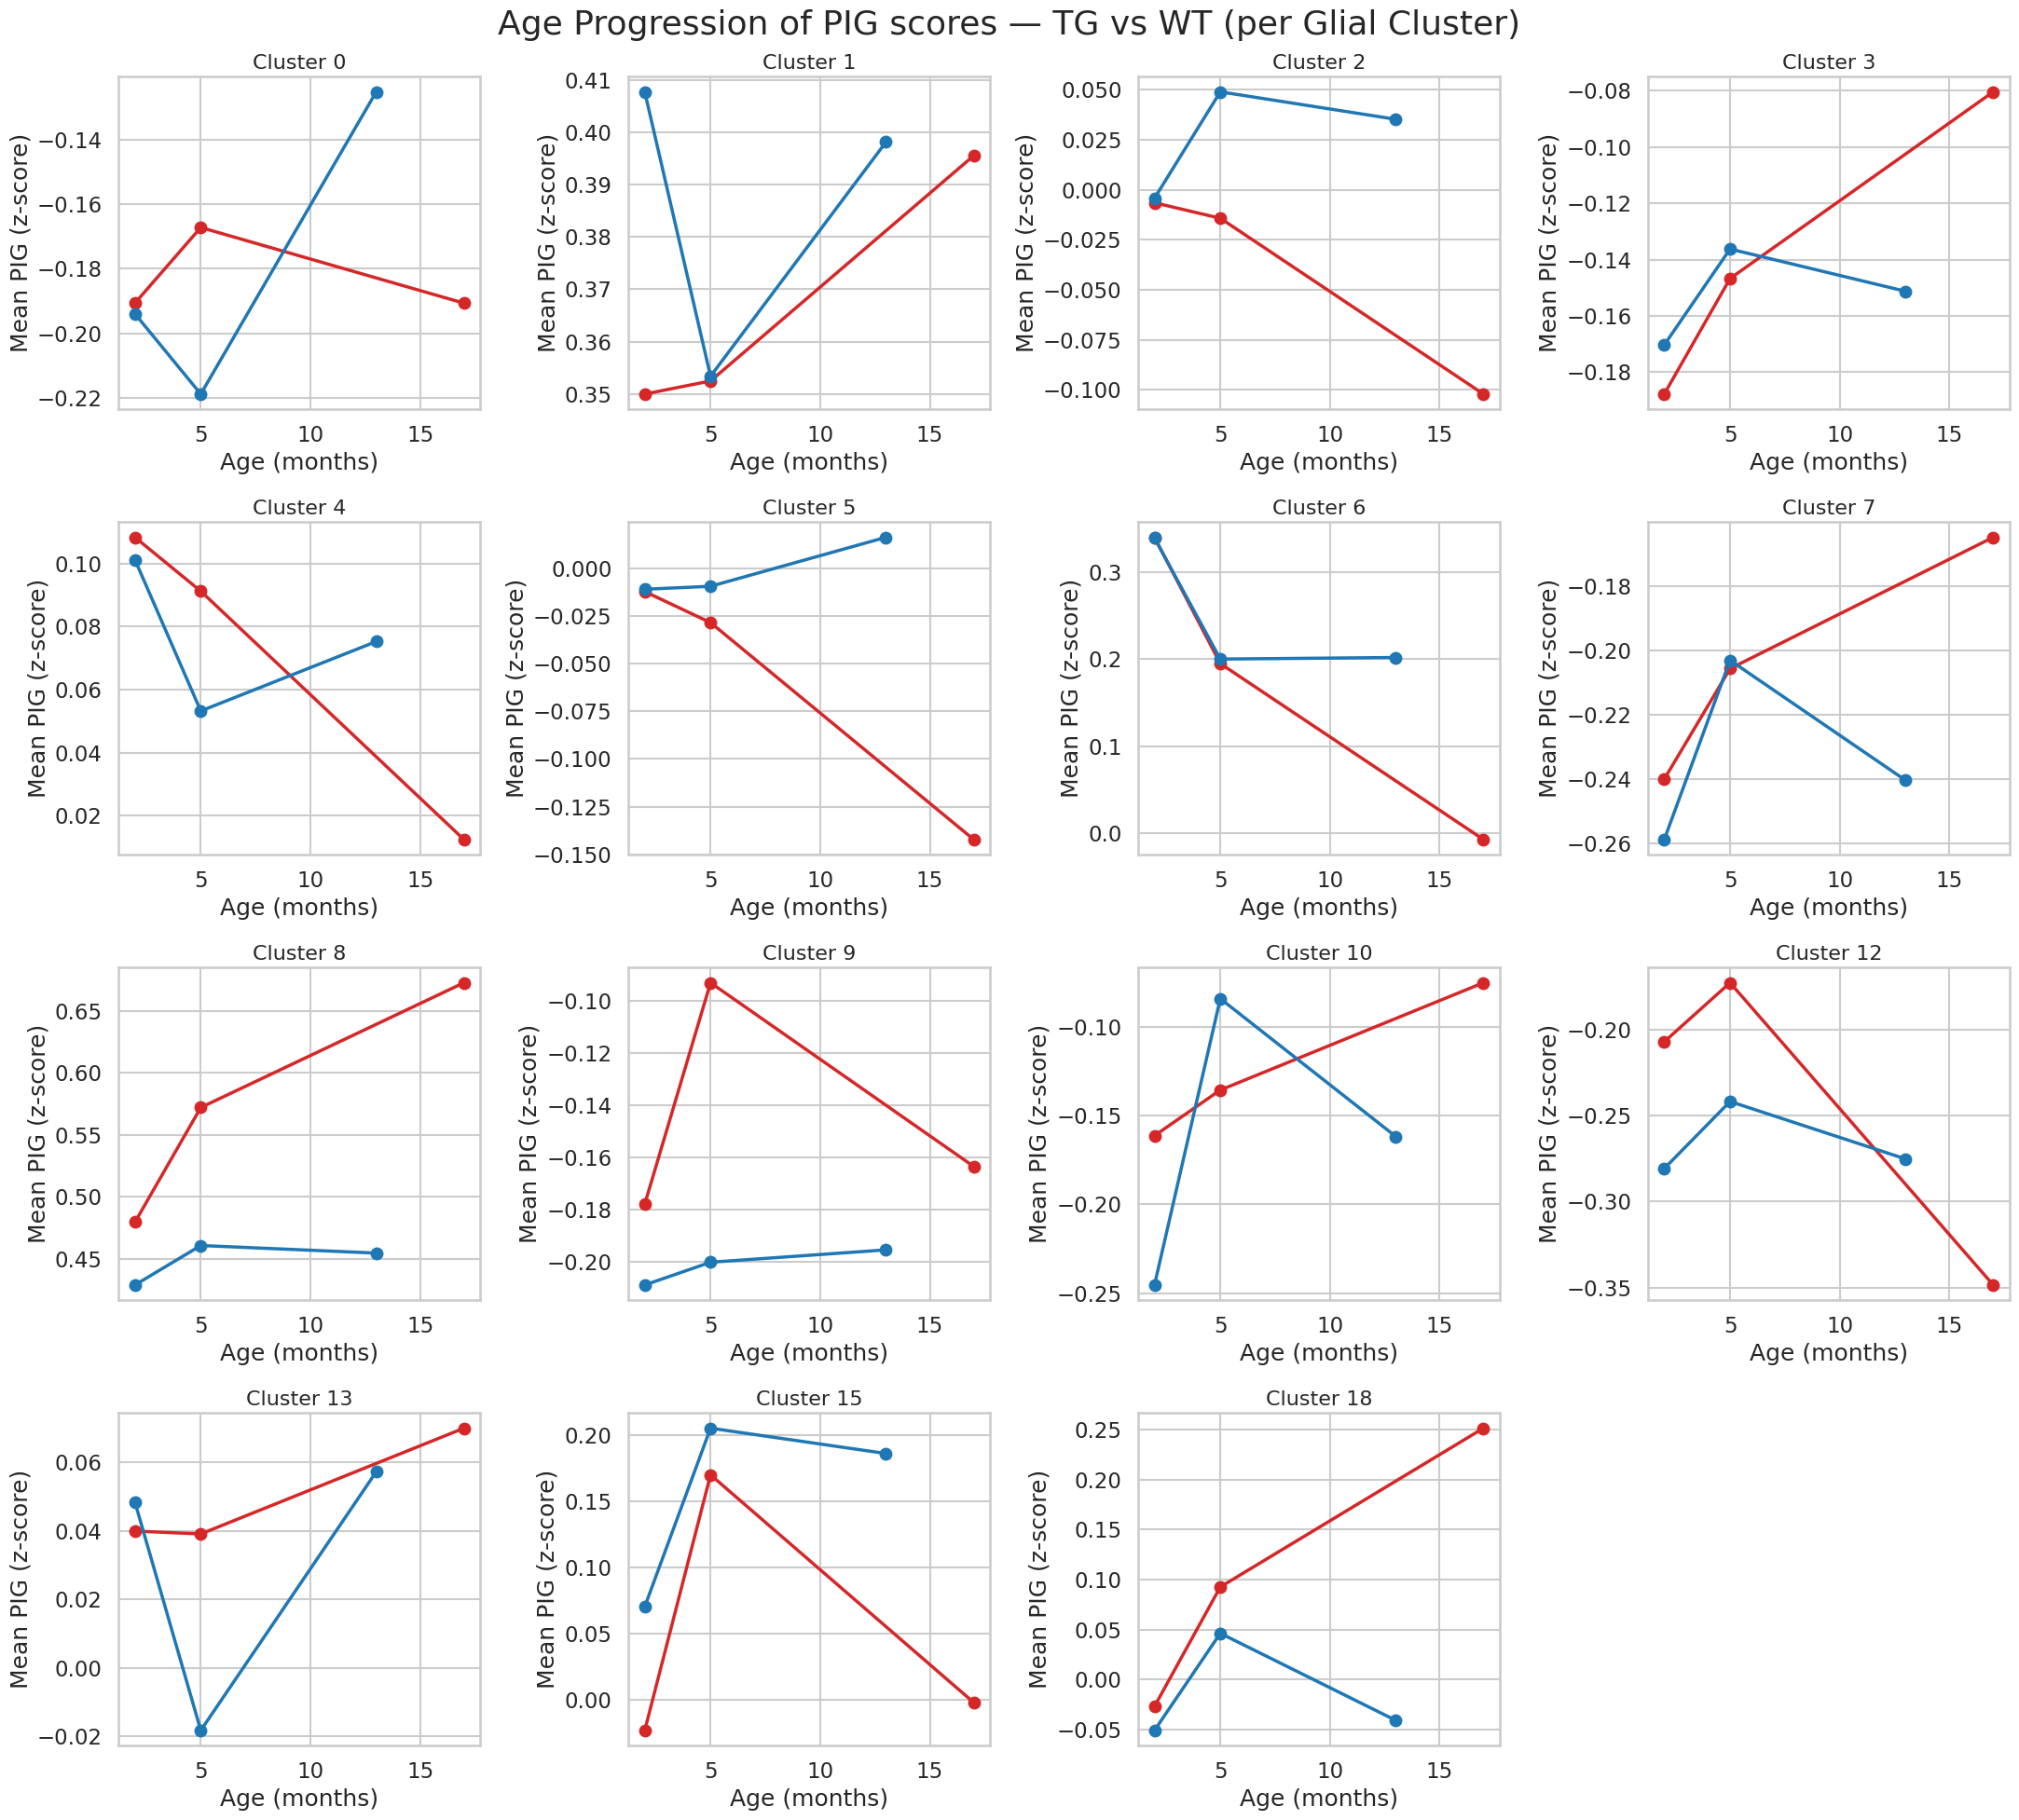

In [128]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

rows = int(np.ceil(len(glial_clusters)/4))
cols = 4

fig, axes = plt.subplots(rows, cols, figsize=(22, 5*rows))
axes = axes.flatten()

for i, c in enumerate(glial_clusters):

    ax = axes[i]
    df_c = pig_glial_df[pig_glial_df["cluster"] == c]

    # TG cells only
    df_tg = df_c[df_c["disease"]=="TG"]\
                 .groupby("age")["mean_pig"].mean().reset_index()

    # WT cells only
    df_wt = df_c[df_c["disease"]=="WT"]\
                 .groupby("age")["mean_pig"].mean().reset_index()

    # Plot TG curve in red
    if len(df_tg) > 0:
        ax.plot(
            df_tg["age"], df_tg["mean_pig"],
            marker="o", linewidth=2.5,
            color="#d62728", label="TG"
        )

    # Plot WT curve in blue
    if len(df_wt) > 0:
        ax.plot(
            df_wt["age"], df_wt["mean_pig"],
            marker="o", linewidth=2.5,
            color="#1f77b4", label="WT"
        )

    ax.set_title(f"Cluster {c}", fontsize=16)
    ax.set_xlabel("Age (months)")
    ax.set_ylabel("Mean PIG (z-score)")

for j in range(i+1, rows*cols):
    fig.delaxes(axes[j])

plt.suptitle("Age Progression of PIG scores — TG vs WT (per Glial Cluster)", fontsize=26)
plt.tight_layout()
plt.show()


In [129]:
disease_specific_genes = {}

for c in glial_clusters:
    tg_cells = []
    wt_cells = []

    for mouse, df in mice_z.items():
        df_c = df[df["cluster_leiden"] == c]
        if disease_map[mouse] == "TG":
            tg_cells.append(df_c[gene_cols])
        else:
            wt_cells.append(df_c[gene_cols])

    if len(tg_cells) == 0 or len(wt_cells) == 0:
        continue

    TG = pd.concat(tg_cells).mean()
    WT = pd.concat(wt_cells).mean()

    df = pd.DataFrame({
        "gene": gene_cols,
        "TG_mean": TG.values,
        "WT_mean": WT.values
    })

    df["logFC"] = df["TG_mean"] - df["WT_mean"]
    df["disease_specific_score"] = df["logFC"] - df["WT_mean"]

    disease_specific_genes[c] = df.sort_values(
        "disease_specific_score", ascending=False
    )

In [130]:
top_specific = {}

for c, df in disease_specific_genes.items():
    top_specific[c] = df.head(10)

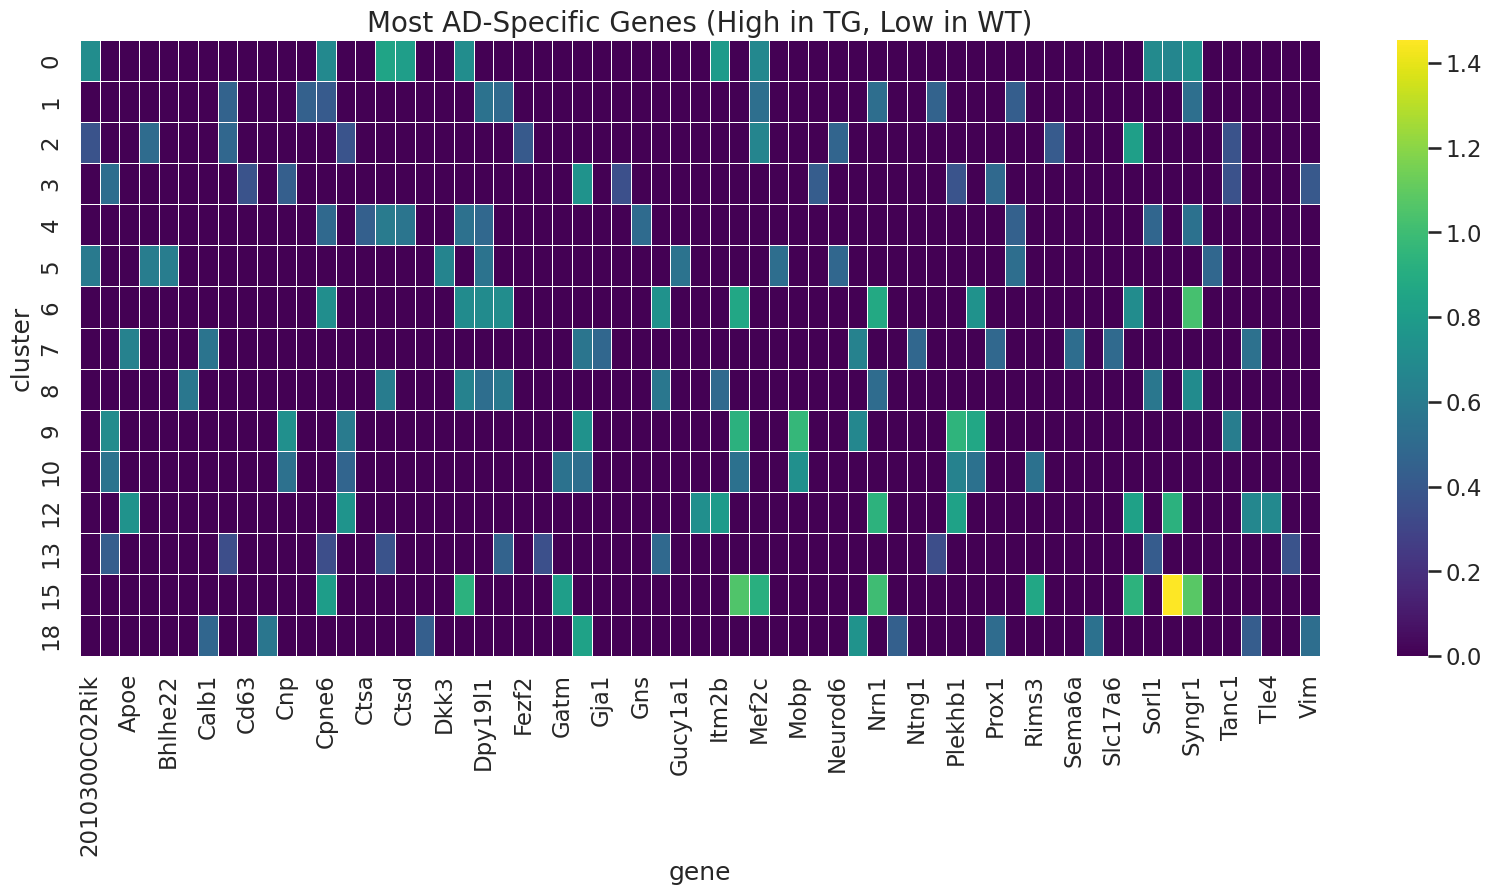

In [131]:
heat_data = []

for c, df in top_specific.items():
    for _, row in df.iterrows():
        heat_data.append({
            "cluster": c,
            "gene": row["gene"],
            "score": row["disease_specific_score"]
        })

heat_df = pd.DataFrame(heat_data)

matrix = heat_df.pivot_table(
    index="cluster",
    columns="gene",
    values="score",
    fill_value=0
)

plt.figure(figsize=(20, 8))
sns.heatmap(matrix, cmap="viridis", linewidths=0.5)
plt.title("Most AD-Specific Genes (High in TG, Low in WT)", fontsize=20)
plt.show()

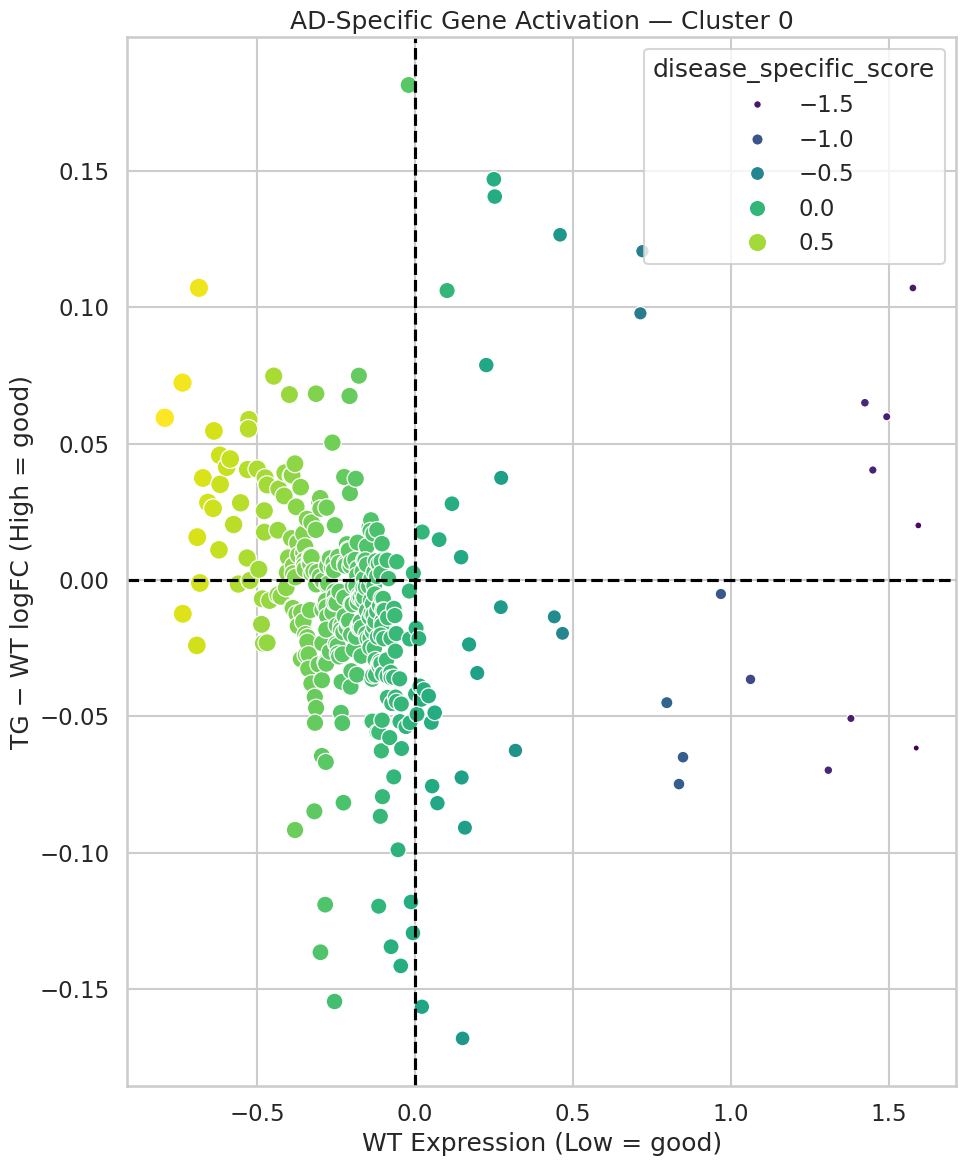

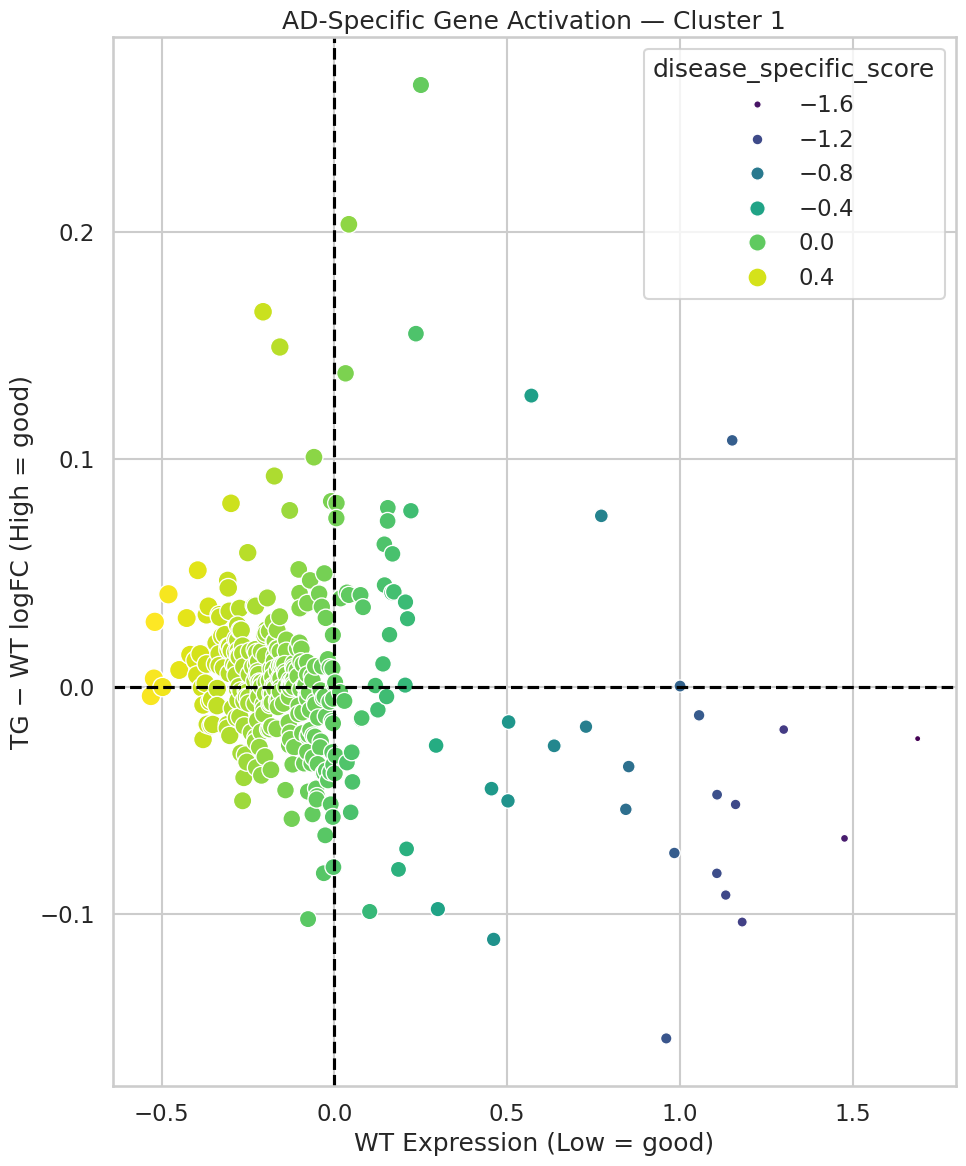

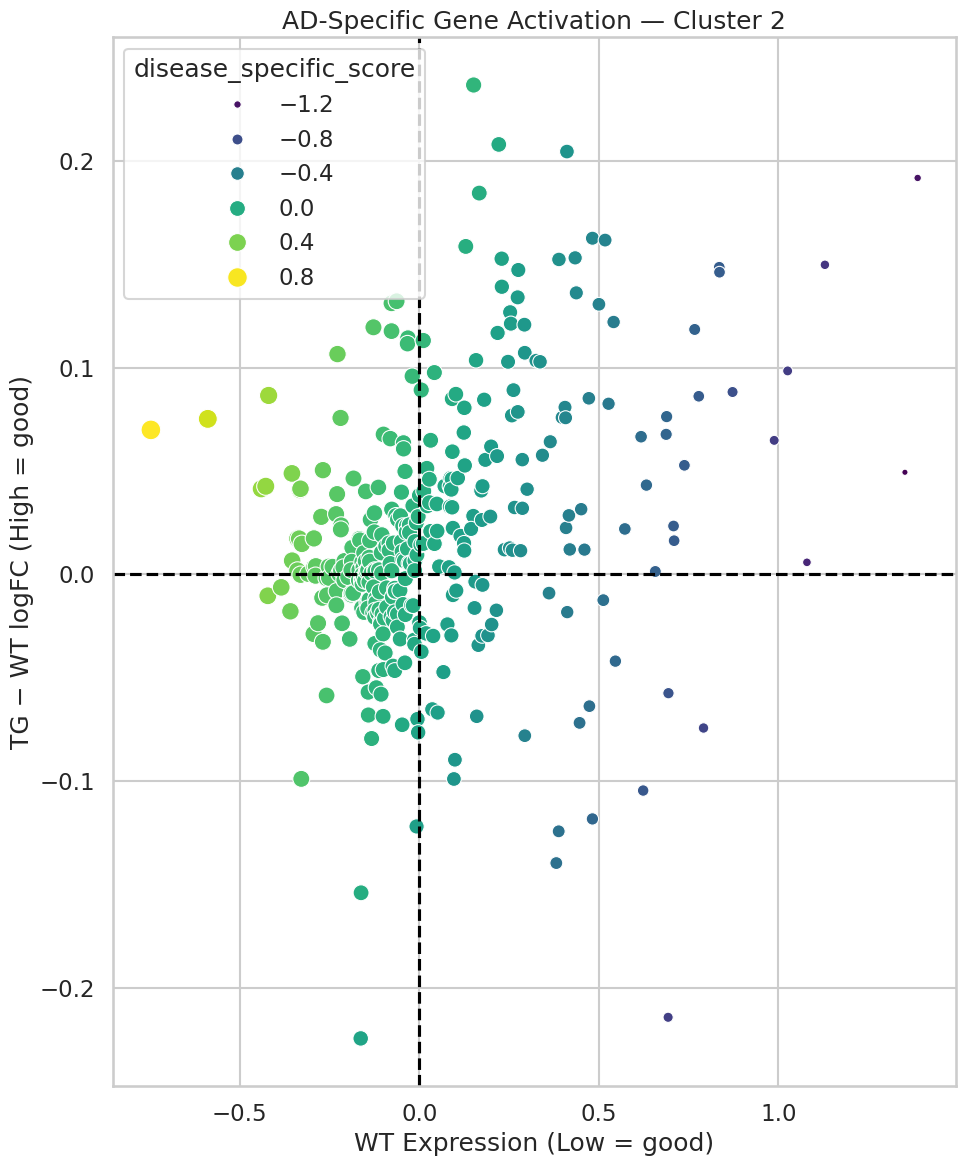

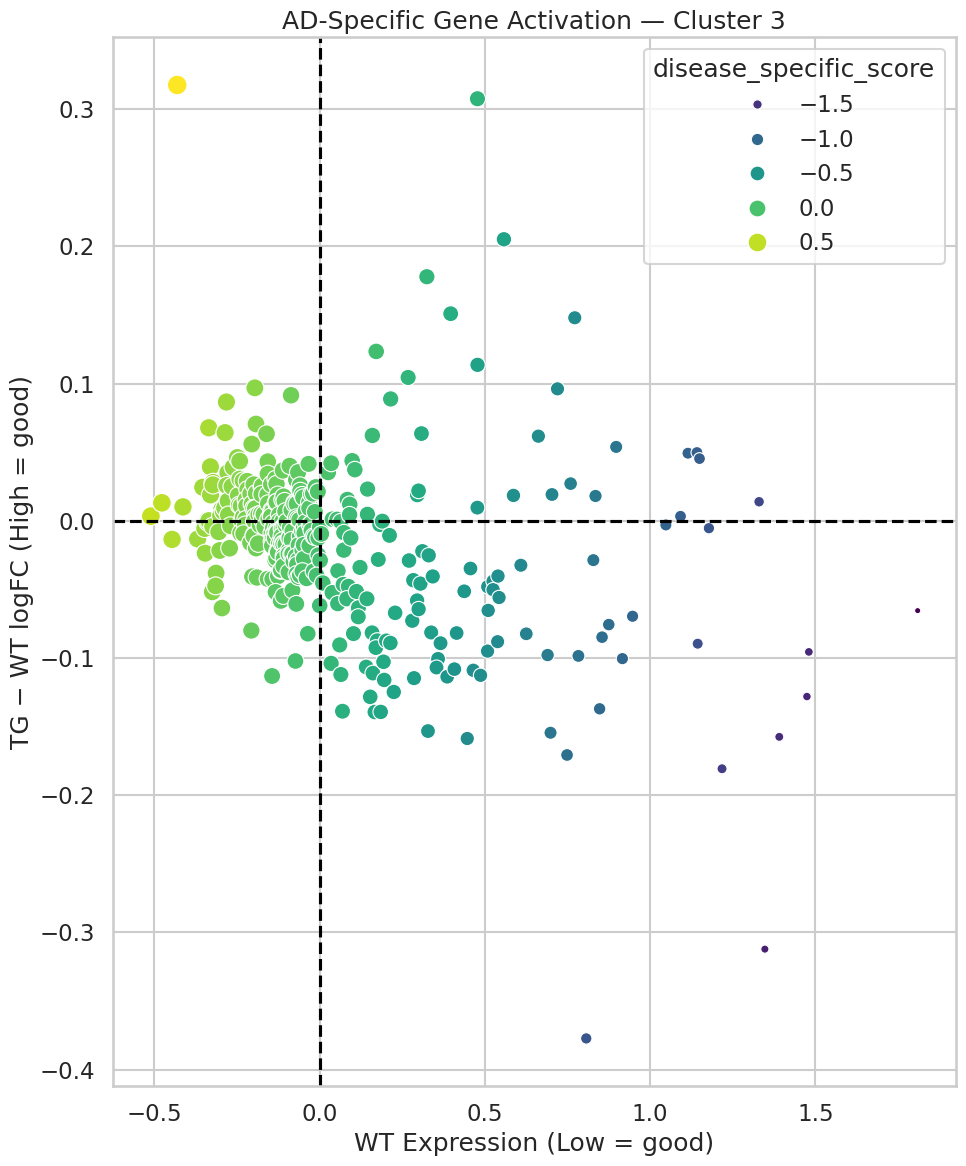

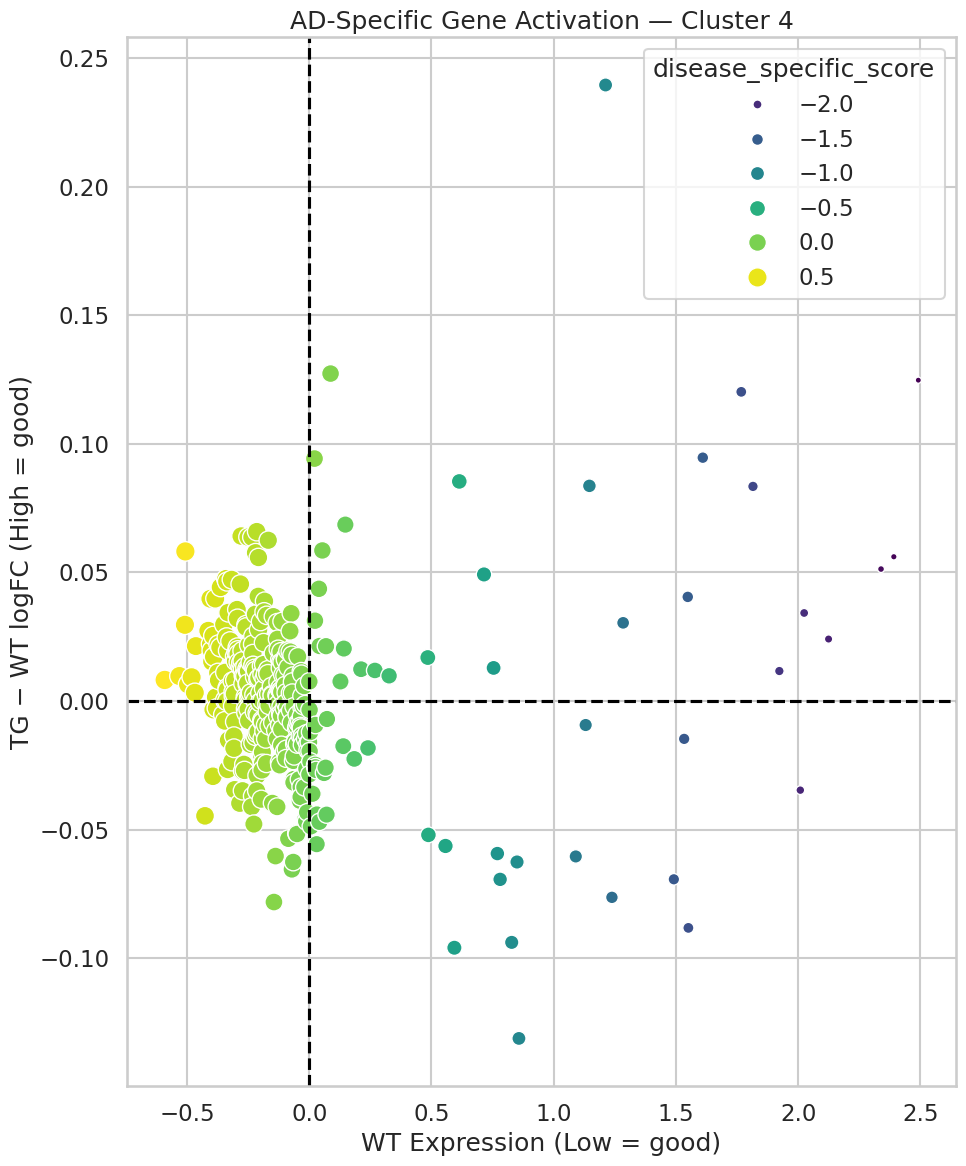

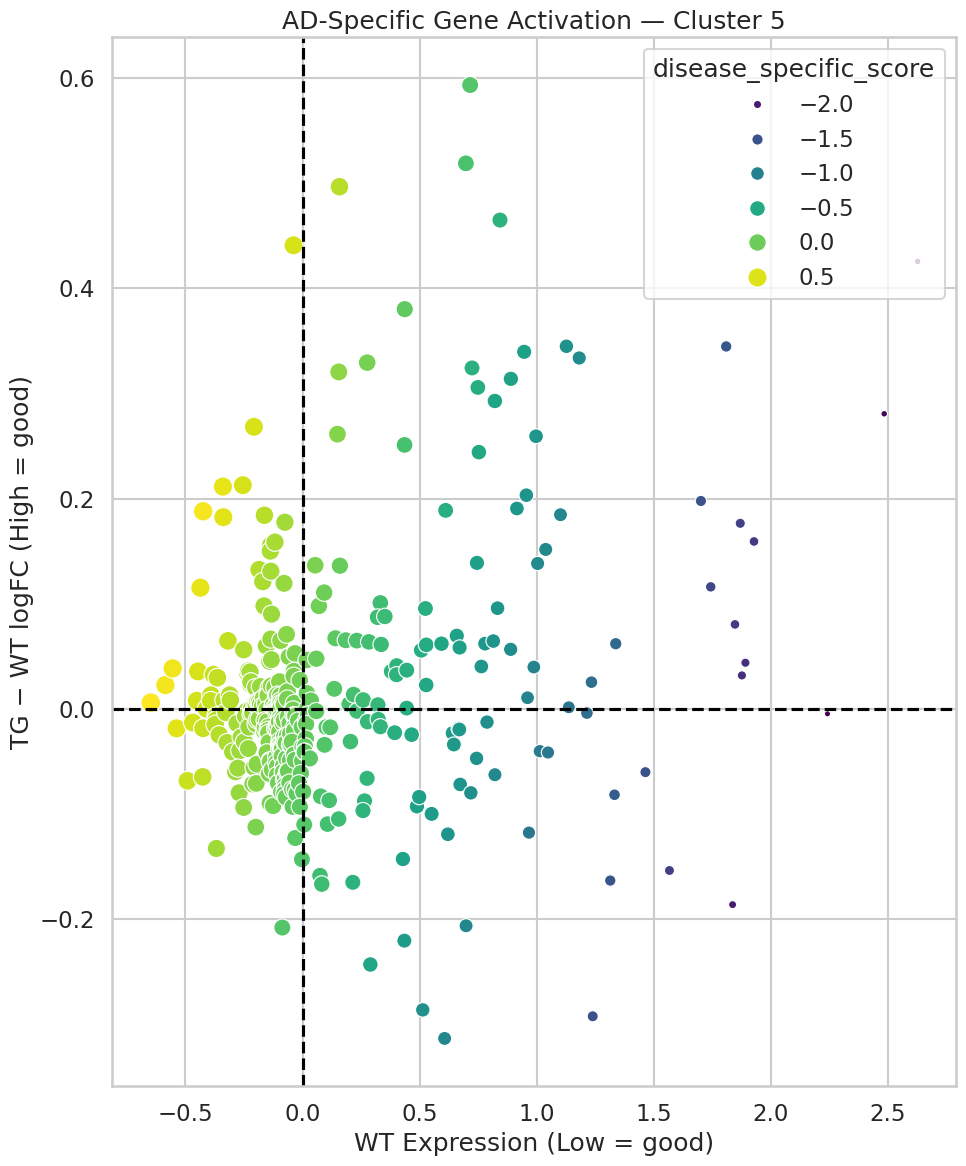

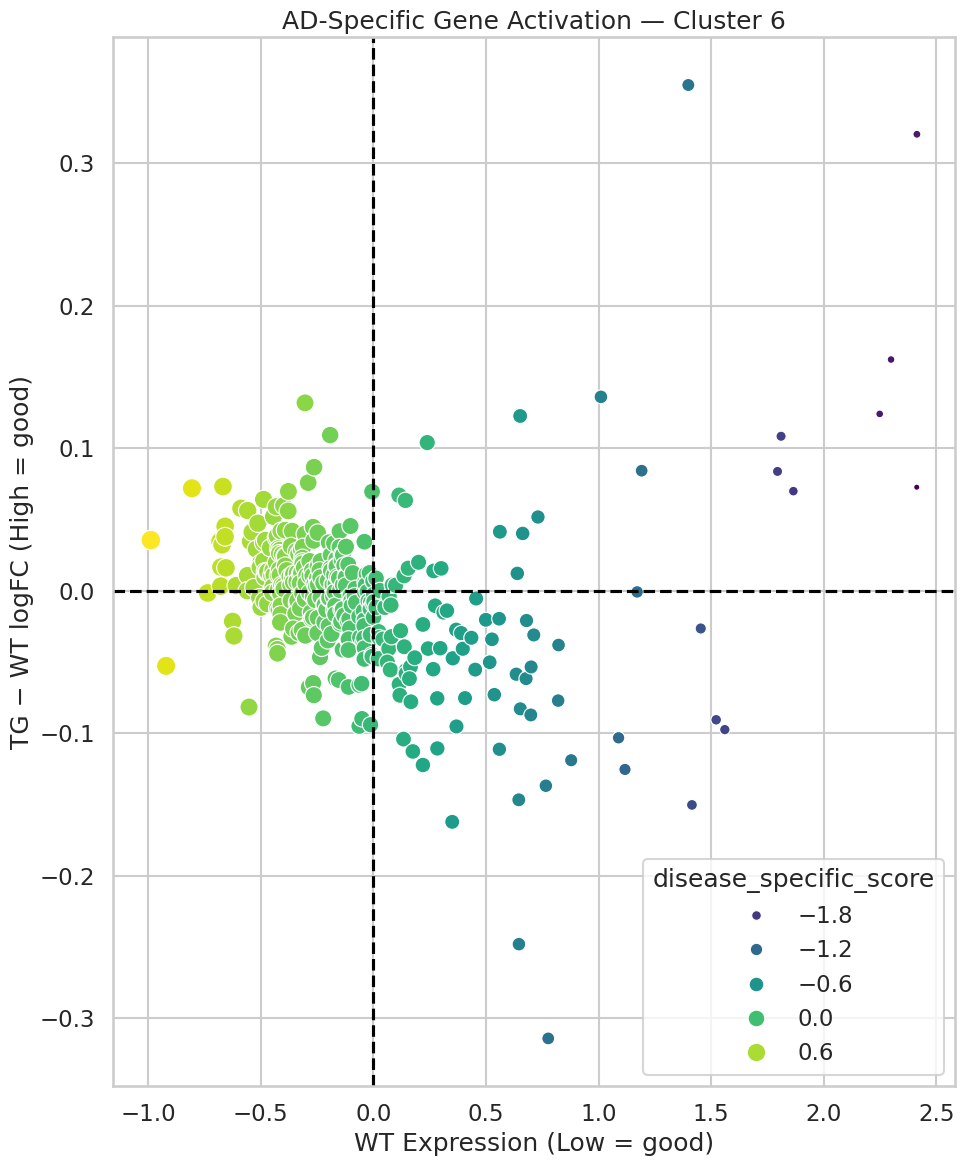

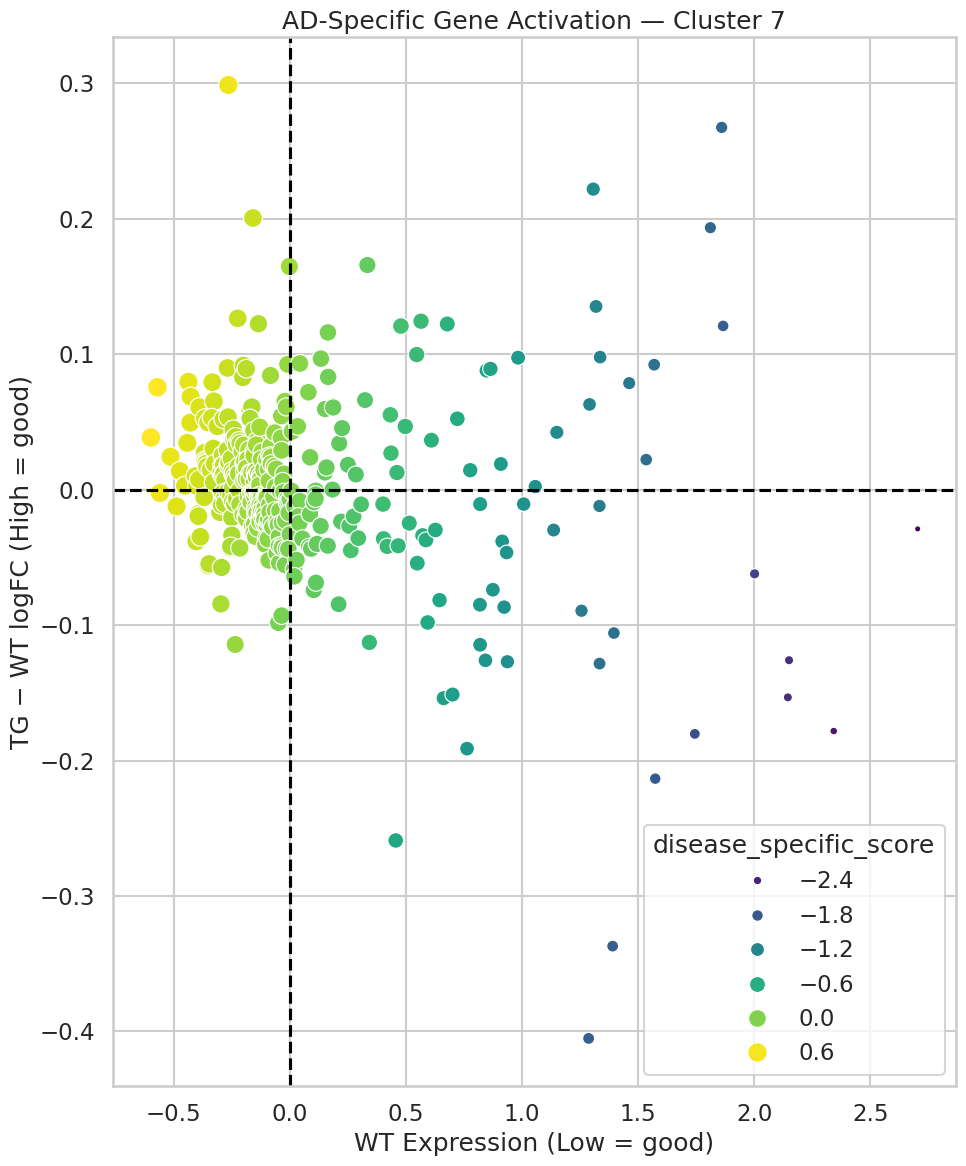

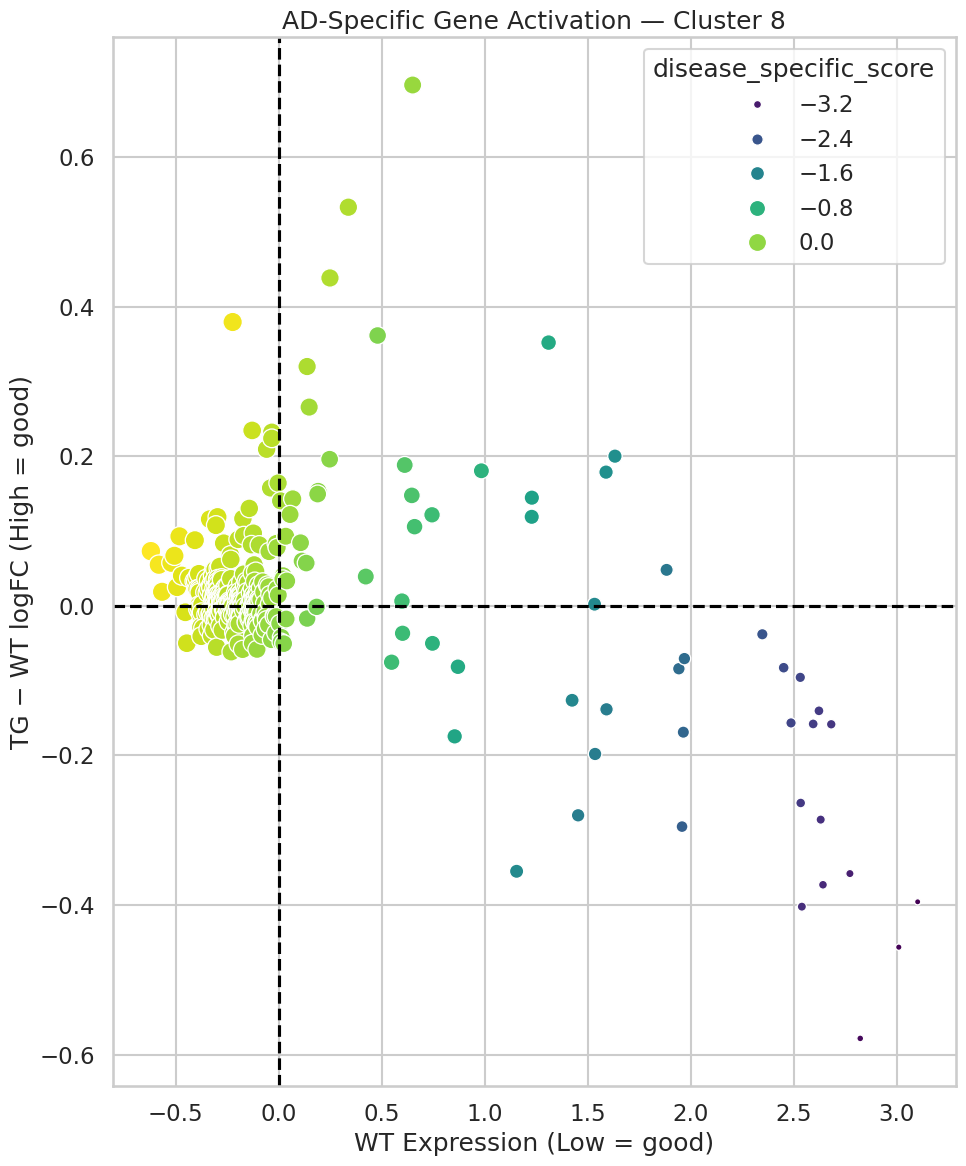

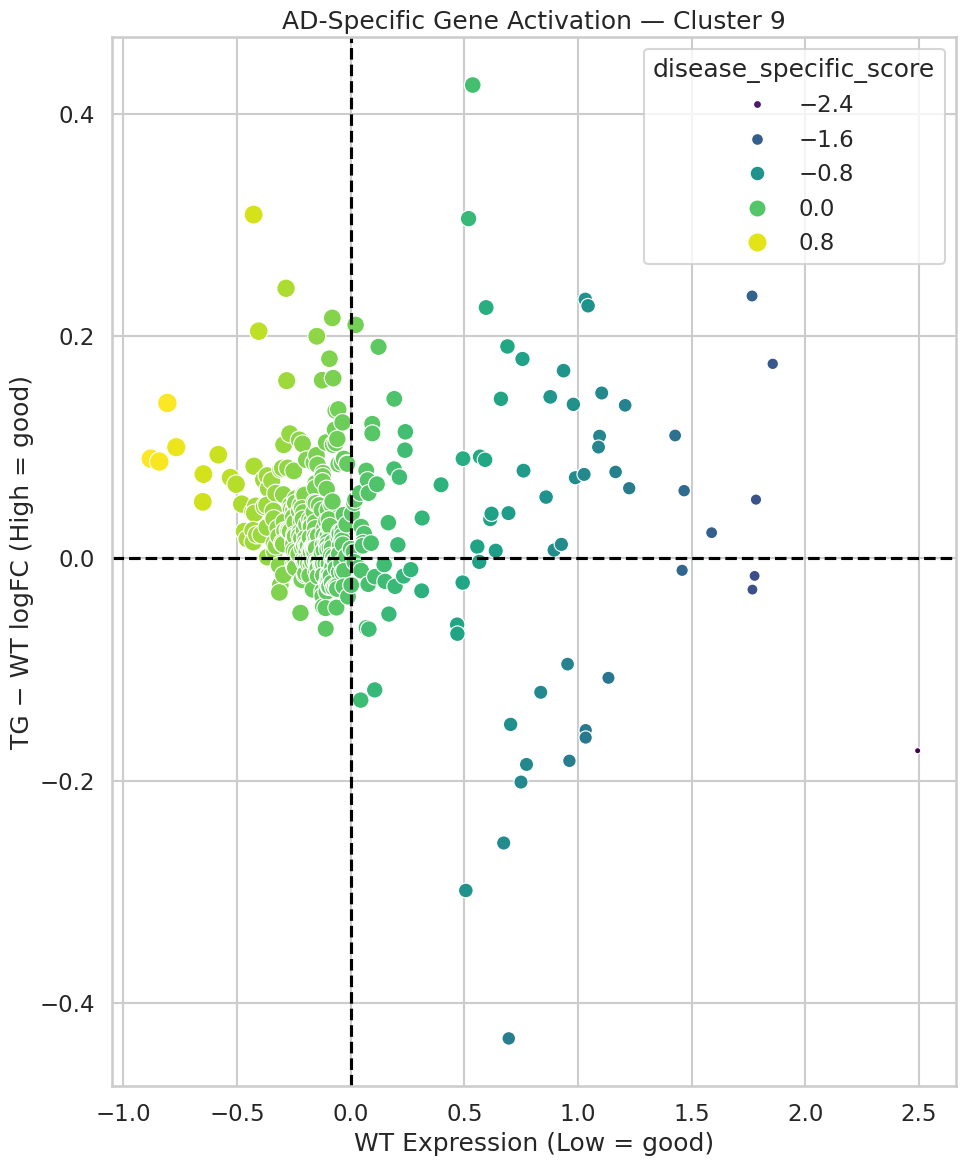

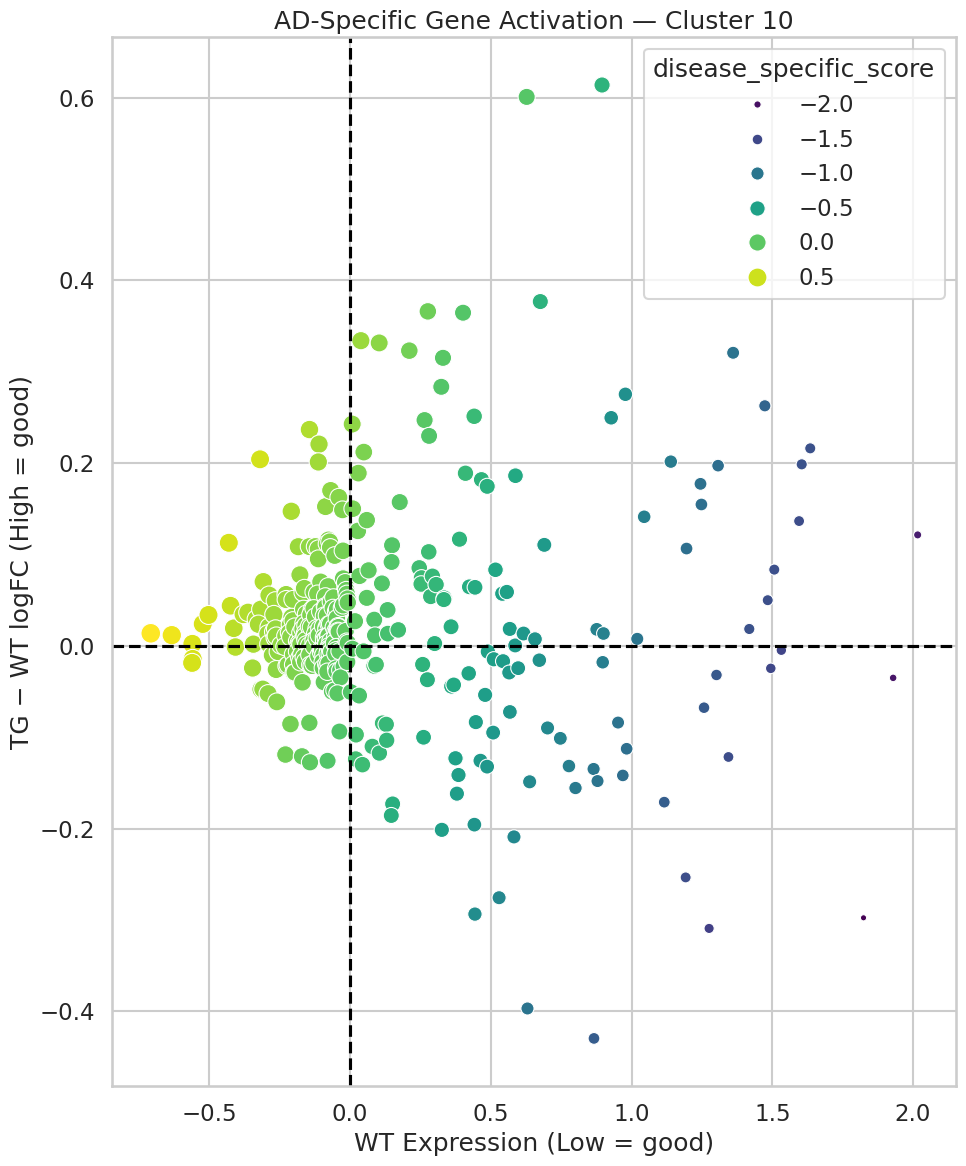

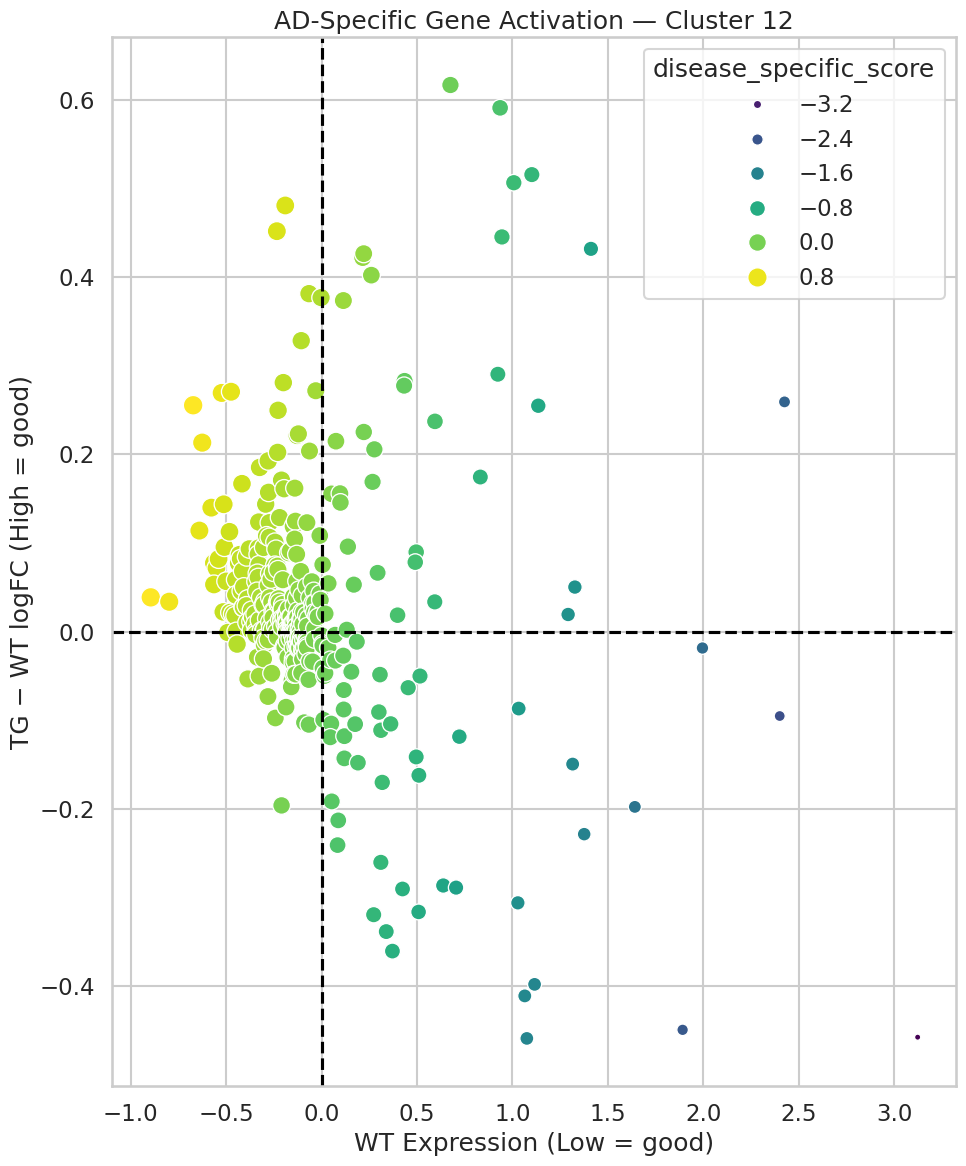

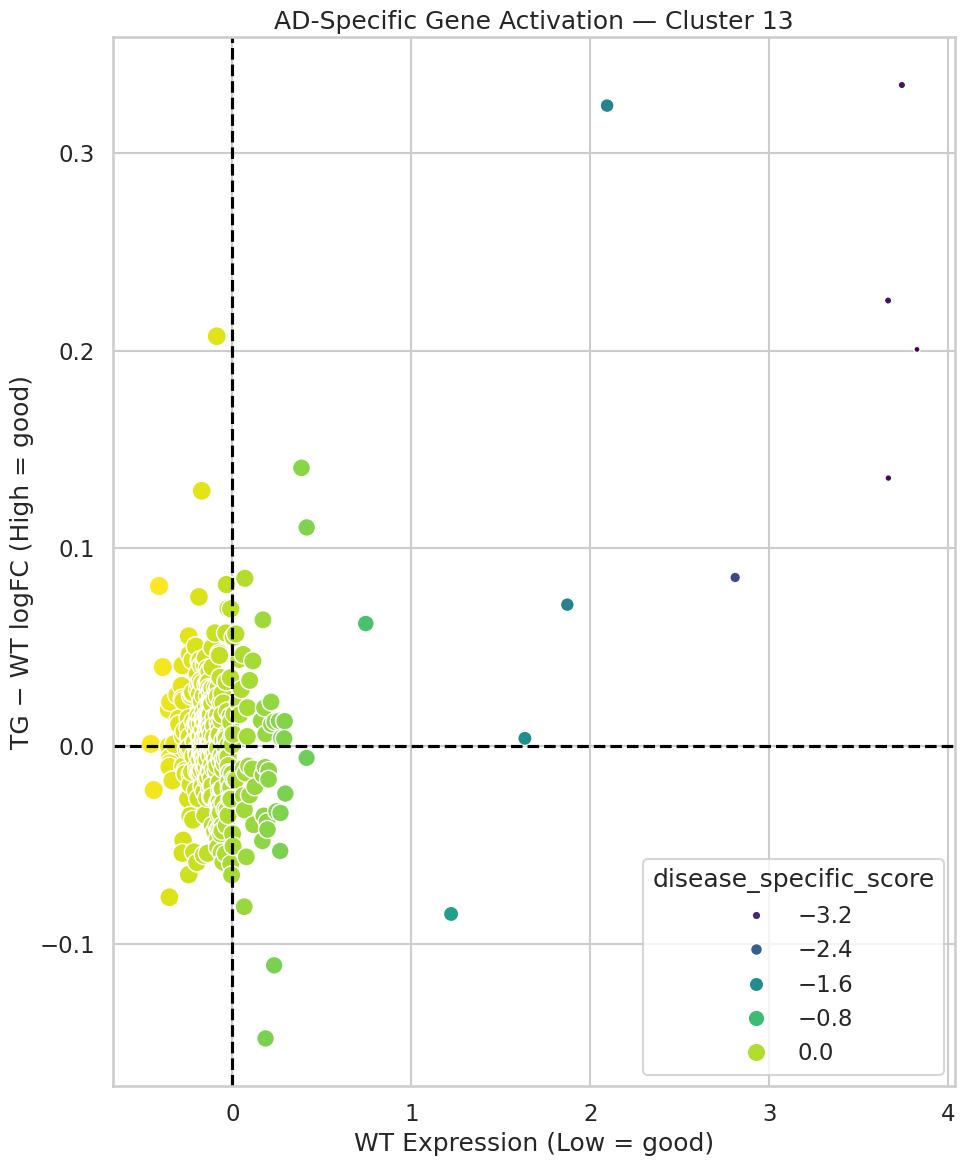

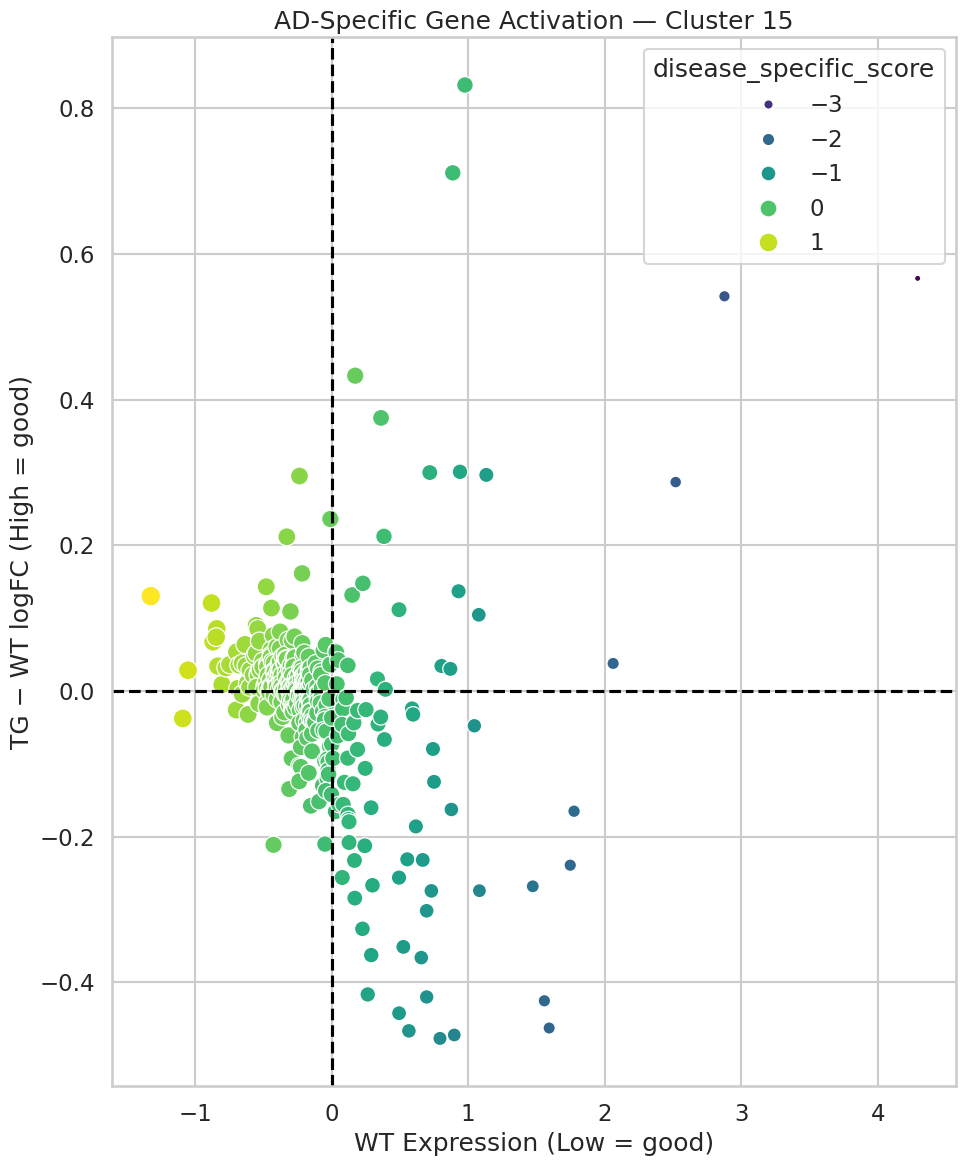

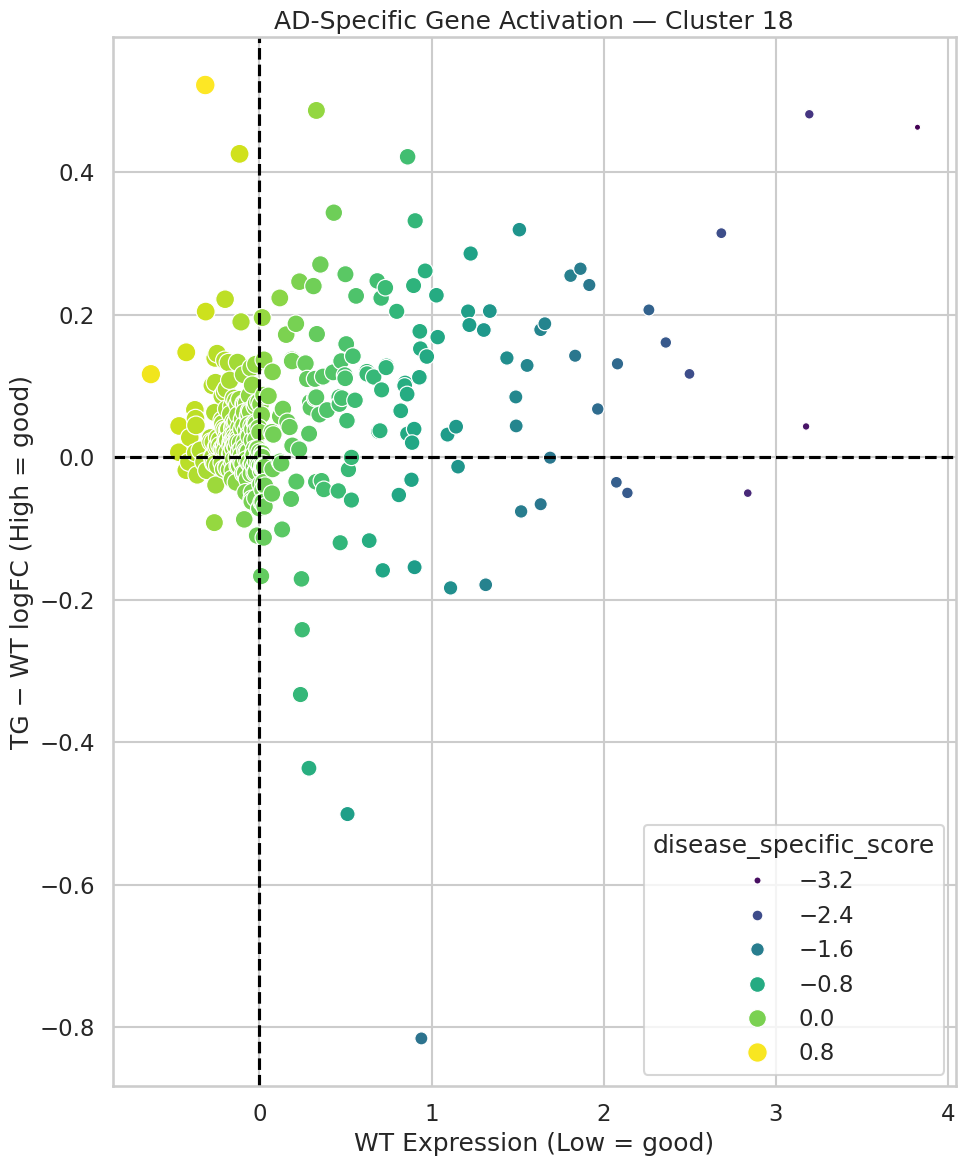

In [140]:
for c, df in disease_specific_genes.items():
    plt.figure(figsize=(10,12))
    sns.scatterplot(
        data=df,
        x="WT_mean",
        y="logFC",
        size="disease_specific_score",
        hue="disease_specific_score",
        palette="viridis",
        sizes=(20,200)
    )
    plt.title(f"AD-Specific Gene Activation — Cluster {c}")
    plt.xlabel("WT Expression (Low = good)")
    plt.ylabel("TG − WT logFC (High = good)")
    plt.axhline(0, color="black", linestyle="--")
    plt.axvline(0, color="black", linestyle="--")
    plt.tight_layout()
    plt.show()

In [137]:
cluster_rank = []

for c, df in disease_specific_genes.items():
    score = df["disease_specific_score"].abs().mean()
    top_gene = df.loc[df["disease_specific_score"].idxmax(), "gene"]
    top_value = df["disease_specific_score"].max()

    cluster_rank.append({
        "cluster": c,
        "mean_AD_specificity": score,
        "top_gene": top_gene,
        "top_gene_score": top_value
    })

cluster_rank_df = pd.DataFrame(cluster_rank)
cluster_rank_df = cluster_rank_df.sort_values("mean_AD_specificity", ascending=False)
cluster_rank_df


,cluster,mean_AD_specificity,top_gene,top_gene_score
8,8,0.420289,Syngr1,0.694467
14,18,0.406769,Gfap,0.837572
13,15,0.405063,Sparcl1,1.453993
6,6,0.375980,Syngr1,1.023805
7,7,0.355922,Nr2f2,0.645709
11,12,0.348448,Nrn1,0.933643
5,5,0.342487,Dkk3,0.654158
10,10,0.336851,Mobp,0.721721
9,9,0.331674,Mobp,0.969180
4,4,0.290247,Ctsb,0.599630


Our initial attempt to model plaque proximity using spatial coordinates alone revealed a fundamental limitation. Although the spatial-only model achieved a deceptively high R² in the 17.9-month transgenic mouse, further analysis showed that this predictive power was entirely artifactual. By comparing the predicted plaque-distance distributions across all Tg and WT animals, we found that the model produced nearly identical means, variances, and distribution shapes in every mouse, regardless of genotype or age. Divergence measures such as Jensen–Shannon distance (approximately 0.05 to 0.16) and Kolmogorov–Smirnov effect sizes (approximately 0.02 to 0.13) confirmed that the distributions were almost indistinguishable. Even the significant ANOVA p-value became irrelevant once effect size was accounted for. These findings demonstrate that the model did not detect plaque-related pathology and instead exploited conserved tissue geometry such as cortical curvature and laminar structure. The high predictive accuracy was therefore driven by anatomical bias rather than biological signal.

Because of this, we shifted from pure spatial prediction toward gene expression based and age-aware analyses. This change was necessary for several reasons. First, plaque-induced transcriptional responses are cell-state specific. Microglia, astrocytes, and some oligodendrocyte populations exhibit strong gene expression changes near plaques that cannot be inferred from spatial position alone. Second, direct normalization of transcriptomic values across different mice is unreliable. Differences in tissue orientation, capture area, imaging depth, and detection efficiency create batch-like distortions that classical approaches such as global scaling or quantile matching cannot safely correct. These adjustments often distort biological gradients or suppress real disease variance. Third, commonly used multi-sample harmonization methods such as Harmony, mutual nearest neighbors, or scVI are not ideal for Xenium data. The gene panel is sparse, the number of cells is very large, and plaque-associated variance is not a batch effect that should be removed. For these reasons, cross-mouse alignment would obscure rather than clarify AD-dependent patterns.

We therefore adopted an approach based on within-cluster and within-gene z-normalized signatures. This avoids all cross-mouse normalization pitfalls while allowing us to isolate expression changes that are cell-type specific, disease dependent, and age progressive. Once this framework was in place, we analyzed two independent biological dimensions: disease status (TG versus WT) and age progression (2 to 5 to 17 months).

For each Leiden cluster, we computed a disease-specific gene activation score that identifies genes highly expressed in Tg mice but minimally expressed in WT controls. This identifies genes whose expression is linked to amyloid pathology rather than to general aging or baseline glial identity. We then ranked clusters by the mean disease specificity of all genes to quantify how selectively each cluster responds to plaques.

This analysis revealed that cluster 8 (microglia) showed the strongest AD-specific activation, followed by cluster 18 (astrocytes) and cluster 15 (glial or perivascular associated). In these clusters, disease-specific genes such as Syngr1, Gfap, and Sparcl1 had large positive specificity scores, indicating strong induction in Tg animals while remaining mostly silent in WT mice. These genes are well-established markers of glial reactivity, complement activation, and inflammatory remodeling, underscoring the biological relevance of the observed signatures.

To ensure that these disease-specific signals were not driven by differences in cell-type abundance, we incorporated TG versus WT differential expression and age progression analyses. TG minus WT effect sizes showed that microglia and astrocytes had the largest positive shifts in PIG expression, confirming true disease-driven activation. When examining age trajectories, Tg mice displayed monotonic increases from 2 to 5 to 17 months in these clusters, whereas WT mice remained stable or declined slightly. This divergence indicates that the transcriptional changes arise from plaque-dependent progressive glial activation rather than normal aging.

Taken together, these analyses show that specific glial clusters, particularly microglia (cluster 8) and astrocytes (cluster 18), undergo robust and progressive transcriptional activation driven by amyloid pathology. These signatures intensify with age in Tg mice but remain absent in age-matched WT animals. This confirms that the responses we observe are AD-specific, age progressive, and localized to biologically relevant glial populations. In contrast to spatial-only modeling, the gene-level and age-resolved strategy yields a stable, interpretable, and pathology-driven understanding of how glial states evolve around amyloid plaques.